Installing dynamax...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.1/157.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 3.5 MB/s eta 0:00:00
Installing protobuf...


2025-11-17 17:19:31.135537: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763399971.327700      87 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763399971.383897      87 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

All packages imported successfully!
Backend: GPU
Devices: 1
  [0] Tesla P100-PCIE-16GB: cuda:0

 GPU acceleration enabled
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Data loaded:
  Train: (10000, 28, 28), dtype=float32
  Test: (2000, 28, 28), dtype=float32

Domain shift applied: both (angle=45.0°)


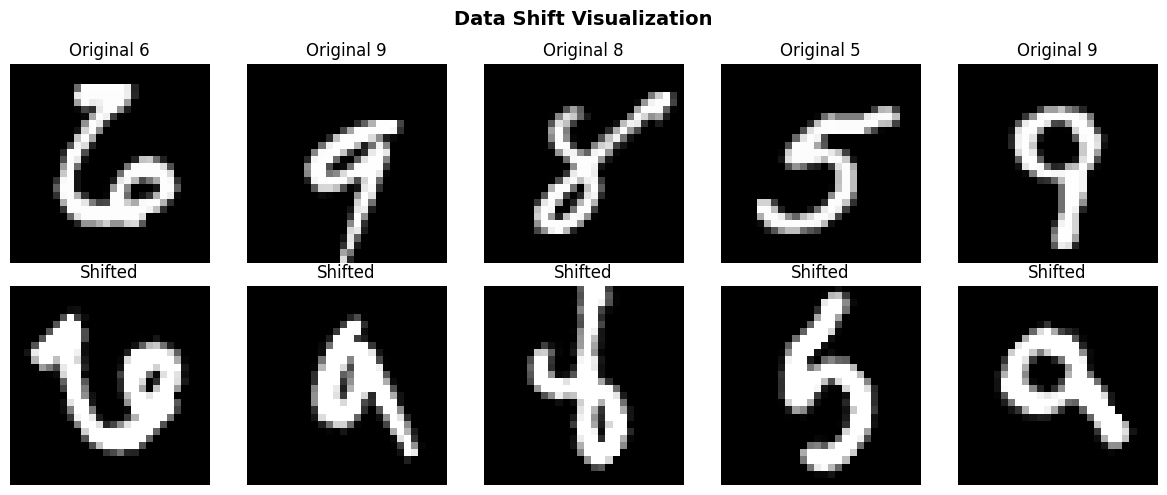

Domain shift visualization saved
Model and utilities defined
Training utilities defined

PRETRAINING (RNNModel)
Epoch 1/10 | Train Loss: 1.8268 | Train Acc: 0.4316 | Test Loss: 1.3244 | Test Acc: 0.6335
Epoch 2/10 | Train Loss: 1.1104 | Train Acc: 0.7109 | Test Loss: 0.9149 | Test Acc: 0.7490
Epoch 3/10 | Train Loss: 0.8207 | Train Acc: 0.7947 | Test Loss: 0.7067 | Test Acc: 0.8035
Epoch 4/10 | Train Loss: 0.6504 | Train Acc: 0.8388 | Test Loss: 0.5617 | Test Acc: 0.8525
Epoch 5/10 | Train Loss: 0.5305 | Train Acc: 0.8711 | Test Loss: 0.4587 | Test Acc: 0.8805
Epoch 6/10 | Train Loss: 0.4429 | Train Acc: 0.8919 | Test Loss: 0.3865 | Test Acc: 0.8980
Epoch 7/10 | Train Loss: 0.3787 | Train Acc: 0.9071 | Test Loss: 0.3347 | Test Acc: 0.9105
Epoch 8/10 | Train Loss: 0.3357 | Train Acc: 0.9162 | Test Loss: 0.3056 | Test Acc: 0.9170
Epoch 9/10 | Train Loss: 0.3001 | Train Acc: 0.9252 | Test Loss: 0.2698 | Test Acc: 0.9245
Epoch 10/10 | Train Loss: 0.2780 | Train Acc: 0.9302 | Test Loss: 0.2

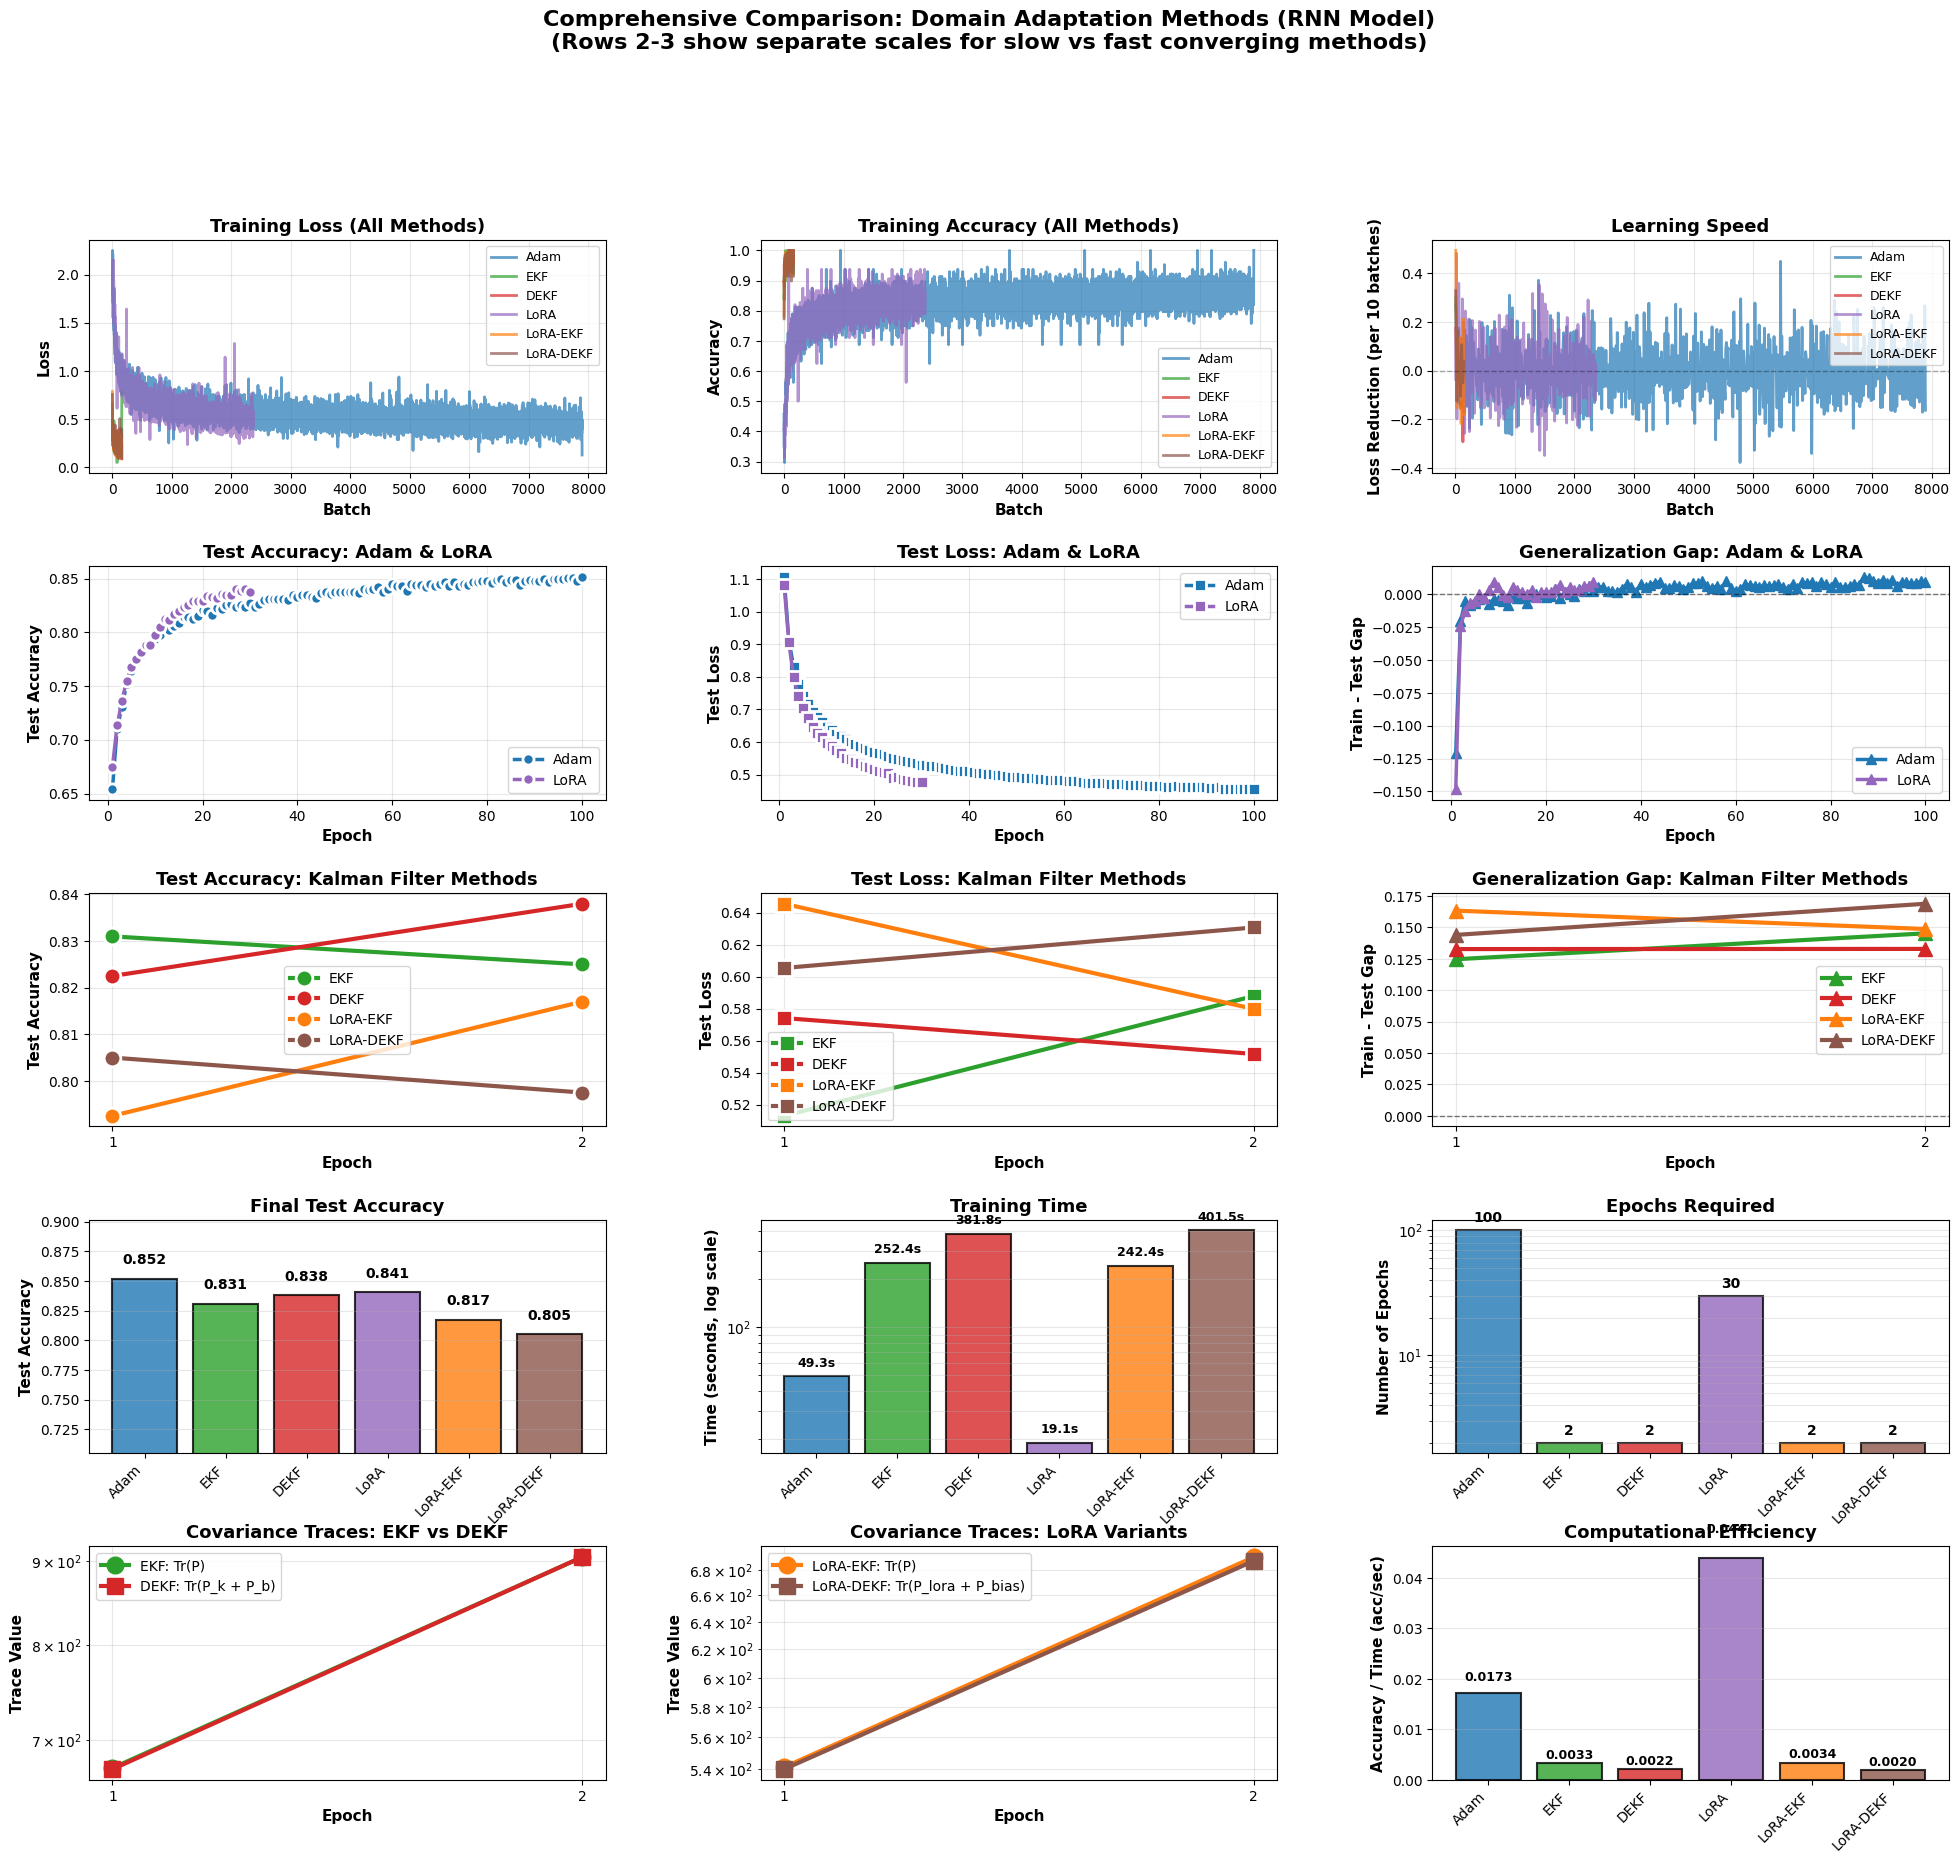


All experiments complete. TensorBoard writer closed.


In [1]:
# ============================================================================
# AUTO-INSTALL AND IMPORTS
# ============================================================================
import subprocess
import sys
def install_if_missing(package):
    try:
        __import__(package.split('[')[0])
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
install_if_missing("dynamax")
install_if_missing("tensorboard")
install_if_missing("scipy")
install_if_missing("protobuf")
import jax
import jax.numpy as jnp
from jax import random, vmap, jit, grad
from jax.extend import backend as jax_backend
from jax.flatten_util import ravel_pytree
import flax.linen as nn
from flax import nnx
# from flax.linen.recurrent import GRU as LinenGRU # <-- REMOVED FAILING IMPORT
from flax.training import train_state
import optax
import numpy as np
from typing import List, Tuple, Dict, Any, Optional
from functools import partial
from dataclasses import dataclass, field
import time
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist as tf_mnist
from torch.utils.tensorboard import SummaryWriter
from dynamax.generalized_gaussian_ssm.models import ParamsGGSSM
from dynamax.generalized_gaussian_ssm.inference import conditional_moments_gaussian_filter, EKFIntegrals
import pickle
import os
print("All packages imported successfully!")
# ============================================================================
# CONFIGURATION AND DEVICE SETUP
# ============================================================================
@dataclass
class Config:
    # Data
    n_train_samples: int = 10000
    n_test_samples: int = 2000
    batch_size: int = 128
    # Domain Shift
    shift_type: str = 'both'  # 'rotation', 'brightness_contrast', or 'both'
    rotation_angle: float = 45.0
    contrast: float = 1.8
    brightness: float = 0.4
    # Model (!!! CHANGED !!!)
    rnn_hidden_size: int = 128  # Changed from hidden_sizes
    num_classes: int = 10
    dropout_rate: float = 0.1
    # Training - PRETRAIN
    pretrain_epochs: int = 10
    pretrain_lr: float = 1e-4
    # Training - PER-METHOD EPOCHS
    adam_epochs: int = 100
    ekf_epochs: int = 2
    dekf_epochs: int = 2
    lora_epochs: int = 30
    lora_ekf_epochs: int = 2
    lora_dekf_epochs: int = 2

    # Learning rates
    finetune_lr: float = 1e-3       # For Adam
    lora_finetune_lr: float = 2e-3    # For LoRA
    # DEKF/EKF
    prior_variance: float = 0.1
    dynamics_sigma: float = 1e-4
    observation_noise: float = 1e-3
    # LoRA
    lora_rank: int = 9
    lora_alpha: float = 16.0
    # Logging and Checkpointing
    print_batch_metrics: bool = False
    checkpoint_metric: str = 'test_acc'  # 'test_acc' or 'test_loss'
    checkpoint_dir: str = '/mnt/user-data/outputs/checkpoints'
    verify_covariance: bool = True
    seed: int = 42
config = Config()
os.makedirs(config.checkpoint_dir, exist_ok=True)
# Device Setup
def setup_device():
    devices = jax.devices()
    backend = jax_backend.get_backend().platform
    print(f"Backend: {backend.upper()}")
    print(f"Devices: {len(devices)}")
    for i, device in enumerate(devices):
        print(f"  [{i}] {device.device_kind}: {device}")
    if backend == 'gpu':
        print(f"\n GPU acceleration enabled")
    elif backend == 'tpu':
        print(f"\n TPU acceleration enabled")
    else:
        print(f"\n CPU only")
    print("="*80)
    return devices[0], backend
device, backend = setup_device()
# ============================================================================
# DATA LOADING AND DOMAIN SHIFT (!!! CHANGED !!!)
# ============================================================================
def load_mnist(normalize=True, n_train_samples=None, n_test_samples=None):
    n_train_samples = n_train_samples or config.n_train_samples
    n_test_samples = n_test_samples or config.n_test_samples
    (X_train, y_train), (X_test, y_test) = tf_mnist.load_data()
    if normalize:
        X_train = X_train.astype(np.float32) / 255.0
        X_test = X_test.astype(np.float32) / 255.0

    # !!! CHANGED !!!
    # Reshape for RNN: (N, 28, 28) -> (Batch, Sequence Length, Features)
    # X_train = X_train.reshape(-1, 28*28) # Old MLP
    # X_test = X_test.reshape(-1, 28*28)  # Old MLP
    X_train = X_train.reshape(-1, 28, 28)
    X_test = X_test.reshape(-1, 28, 28)
    # !!! END CHANGE !!!

    # Subsample
    rng = np.random.RandomState(config.seed)
    train_idx = rng.choice(len(X_train), n_train_samples, replace=False)
    test_idx = rng.choice(len(X_test), n_test_samples, replace=False)
    X_train = X_train[train_idx]
    y_train = y_train[train_idx]
    X_test = X_test[test_idx]
    y_test = y_test[test_idx]
    X_train = jnp.array(X_train, dtype=jnp.float32)
    X_test = jnp.array(X_test, dtype=jnp.float32)
    y_train = jnp.array(y_train, dtype=jnp.int32)
    y_test = jnp.array(y_test, dtype=jnp.int32)
    print(f"Data loaded:")
    print(f"  Train: {X_train.shape}, dtype={X_train.dtype}")
    print(f"  Test: {X_test.shape}, dtype={X_test.dtype}")
    return X_train, y_train, X_test, y_test
def apply_domain_shift(X, shift_type='brightness_contrast', contrast=1.8, brightness=0.4, rotation_angle=45):
    # X shape is (N, 28, 28) from load_mnist
    X_reshaped = X
    if shift_type == 'brightness_contrast':
        X_shifted = np.clip(((X_reshaped - 0.5) * contrast + 0.5) + brightness, 0, 1)
    elif shift_type == 'rotation':
        from scipy.ndimage import rotate
        X_shifted = np.array([rotate(img, rotation_angle, reshape=False, order=1, mode='constant', cval=0.0)
                                for img in X_reshaped])
    elif shift_type == 'both':
        from scipy.ndimage import rotate
        X_rotated = np.array([rotate(img, rotation_angle, reshape=False, order=1, mode='constant', cval=0.0)
                                for img in X_reshaped])
        X_shifted = np.clip(((X_rotated - 0.5) * contrast + 0.5) + brightness, 0, 1)
    else:
        X_shifted = X_reshaped

    # !!! CHANGED !!!
    # Ensure output shape is (N, 28, 28) for the RNN
    # X_shifted = X_shifted.reshape(-1, 28*28) # Old MLP
    X_shifted = X_shifted.reshape(-1, 28, 28)
    # !!! END CHANGE !!!

    return jnp.array(X_shifted, dtype=jnp.float32)
# Load data
X_train, y_train, X_test, y_test = load_mnist()
# Apply domain shift
X_train_shifted = apply_domain_shift(X_train, shift_type=config.shift_type,
                                     rotation_angle=config.rotation_angle,
                                     contrast=config.contrast,
                                     brightness=config.brightness)
X_test_shifted = apply_domain_shift(X_test, shift_type=config.shift_type,
                                    rotation_angle=config.rotation_angle,
                                    contrast=config.contrast,
                                    brightness=config.brightness)
print(f"\nDomain shift applied: {config.shift_type} (angle={config.rotation_angle}°)")
# Visualize domain shift
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0, i].imshow(X_test[i].reshape(28, 28), cmap='gray') # Reshape for plotting
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Original {y_test[i]}')
    axes[1, i].imshow(X_test_shifted[i].reshape(28, 28), cmap='gray') # Reshape for plotting
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Shifted')
plt.suptitle('Data Shift Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/domain_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print("Domain shift visualization saved")
# ============================================================================
# MODEL DEFINITION AND UTILITIES (!!! MANUAL RNN !!!)
# ============================================================================

# !!! NEW RNN MODEL (MANUALLY DEFINED) !!!
class RNNModel(nnx.Module):
    def __init__(self, rnn_hidden_size: int, num_classes: int, rngs: nnx.Rngs):
        self.input_features = 28   # Each timestep has 28 pixels
        self.rnn_hidden_size = rnn_hidden_size
        self.num_classes = num_classes

        # ============================================================
        # FIRST RNN LAYER
        # ============================================================
        key_ih1, key_hh1 = jax.random.split(rngs.params(), 2)

        # Input → Hidden (Layer 1)
        self.W_ih = nnx.Param(jax.nn.initializers.glorot_uniform()(
            key_ih1, (self.input_features, self.rnn_hidden_size)
        ))
        self.b_ih = nnx.Param(jnp.zeros((self.rnn_hidden_size,)))

        # Hidden → Hidden (Layer 1)
        self.W_hh = nnx.Param(jax.nn.initializers.orthogonal()(
            key_hh1, (self.rnn_hidden_size, self.rnn_hidden_size)
        ))
        self.b_hh = nnx.Param(jnp.zeros((self.rnn_hidden_size,)))

        # ============================================================
        # SECOND RNN LAYER  (NEW)
        # ============================================================
        key_ih2, key_hh2 = jax.random.split(rngs.params(), 2)

        # Hidden (L1) → Hidden (L2)
        self.W_ih2 = nnx.Param(jax.nn.initializers.glorot_uniform()(
            key_ih2, (self.rnn_hidden_size, self.rnn_hidden_size)
        ))
        self.b_ih2 = nnx.Param(jnp.zeros((self.rnn_hidden_size,)))

        # Recurrent transform for layer 2
        self.W_hh2 = nnx.Param(jax.nn.initializers.orthogonal()(
            key_hh2, (self.rnn_hidden_size, self.rnn_hidden_size)
        ))
        self.b_hh2 = nnx.Param(jnp.zeros((self.rnn_hidden_size,)))

        # ============================================================
        # DROPOUT + OUTPUT HEAD  (UNCHANGED)
        # ============================================================
        self.dropout = nnx.Dropout(rate=config.dropout_rate, rngs=rngs)

        self.output = nnx.Linear(
            in_features=rnn_hidden_size,
            out_features=num_classes,
            rngs=rngs
        )

    def __call__(self, x, training: bool = False):
        # x shape: (batch_size, seq_len=28, features=28)

        # 1. Get features from RNN
        features = self.extract_features(x)

        # 2. Apply dropout if training
        if training:
            features = self.dropout(features)

        # 3. Apply the 'output' layer
        return self.output(features)

    def extract_features(self, x):
        # This method implements the core RNN logic.
        # It provides the features that are fed into the final 'output' layer.
        # x shape: (batch_size, seq_len=28, features=28)

        batch_size = x.shape[0]

        # 1. Define the RNN step function (h_t = tanh(W_ih*x_t + W_hh*h_t-1))
        def rnn_step(h_prev, x_t):
            # h_prev shape: (batch_size, hidden_size)
            # x_t shape: (batch_size, input_features)

            # Simple RNN equation
            h_t = jax.nn.tanh(
                (x_t @ self.W_ih.value) + self.b_ih.value +
                (h_prev @ self.W_hh.value) + self.b_hh.value
            )

            # The new hidden state (h_t) is the carry for the next step
            # We also output h_t as the result for this time-step
            return h_t, h_t

        # 2. Initialize the first hidden state (h_0) to zeros
        h_0 = jnp.zeros((batch_size, self.rnn_hidden_size))

        # 3. jax.lax.scan requires time to be the first dimension
        # Reshape x from (batch, time, features) to (time, batch, features)
        x_time_first = jnp.swapaxes(x, 0, 1)

        # 4. Run the scan
        # This loops rnn_step over all time-steps in x_time_first
        # final_carry is the *last* hidden state (h_T)
        # all_hiddens is a stack of *all* hidden states (h_1 ... h_T)
        # FIRST LAYER
        h1_0 = jnp.zeros((batch_size, self.rnn_hidden_size))
        _, h1_all = jax.lax.scan(rnn_step, h1_0, x_time_first)
        
        # SECOND LAYER STEP
        def rnn_step2(h_prev, x_t):
            h_t = jax.nn.tanh(
                (x_t @ self.W_ih2.value) + self.b_ih2.value +
                (h_prev @ self.W_hh2.value) + self.b_hh2.value
            )
            return h_t, h_t
        
        # SECOND LAYER INPUT = first layer hidden states
        _, h2_all = jax.lax.scan(rnn_step2, jnp.zeros_like(h1_0), h1_all)
        
        # FINAL RNN FEATURE = last hidden state of second layer
        return h2_all[-1]


# Loss and Metrics
@jit
def cross_entropy_loss(logits, labels):
    one_hot = jax.nn.one_hot(labels, config.num_classes)
    return -jnp.mean(jnp.sum(one_hot * jax.nn.log_softmax(logits), axis=-1))
@jit
def compute_accuracy(logits, labels):
    predictions = jnp.argmax(logits, axis=-1)
    return jnp.mean(predictions == labels)
# Covariance Verification
def verify_covariance_matrix(P, name="P", step=0):
    if not config.verify_covariance:
        return
    is_symmetric = jnp.allclose(P, P.T, atol=1e-6)
    eigenvalues = jnp.linalg.eigvalsh(P)
    min_eigenvalue = jnp.min(eigenvalues)
    is_psd = min_eigenvalue >= -1e-6
    trace = jnp.trace(P)
    frobenius_norm = jnp.linalg.norm(P, 'fro')
    if step % 50 == 0:
        print(f"     [{name} @step {step}] Symmetric: {is_symmetric}, PSD: {is_psd}, "
              f"Tr: {trace:.2e}, ||P||_F: {frobenius_norm:.2e}, λ_min: {min_eigenvalue:.2e}")
    if not is_symmetric:
        print(f"     WARNING: {name} is not symmetric at step {step}!")
    if not is_psd:
        print(f"     WARNING: {name} is not PSD at step {step}! Min eigenvalue: {min_eigenvalue:.2e}")
def compare_covariances(P_prev, P_curr, name="P", step=0):
    if not config.verify_covariance or P_prev is None:
        return
    diff_norm = jnp.linalg.norm(P_curr - P_prev, 'fro')
    relative_change = diff_norm / (jnp.linalg.norm(P_prev, 'fro') + 1e-10)
    if step % 50 == 0:
        print(f"     [{name} @step {step}] ||P_curr - P_prev||_F: {diff_norm:.2e}, "
              f"Relative change: {relative_change:.4f}")
print("Model and utilities defined")
# ============================================================================
# PRETRAINING SETUP
# ============================================================================
class TrainState(train_state.TrainState):
    graphdef: Any = None
    output_graphdef: Any = None
    full_other_states: Any = None
    output_other_states: Any = None
def create_train_state(model, learning_rate):
    """Create train state for FULL model (all parameters)"""
    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    tx = optax.adam(learning_rate)
    def apply_fn(params, x, training=False):
        model_copy = nnx.merge(graphdef, params, other_states)
        return model_copy(x, training=training)
    return TrainState.create(
        apply_fn=apply_fn,
        params=params,
        tx=tx,
        graphdef=graphdef
    )
def create_output_only_train_state(model, learning_rate):
    """Create train state for LAST LAYER ONLY"""
    output_layer = model.output
    output_graphdef, output_params, output_other_states = nnx.split(output_layer, nnx.Param, ...)
    full_graphdef, full_params, full_other_states = nnx.split(model, nnx.Param, ...)
    tx = optax.adam(learning_rate)

    # This apply_fn relies on model.extract_features()
    # It will work perfectly with the new RNNModel
    def apply_fn(output_params, x, training=False):
        # Reconstruct frozen base model
        model_copy = nnx.merge(full_graphdef, full_params, full_other_states)
        # Extract features WITHOUT dropout (eval mode for frozen layers)
        features = model_copy.extract_features(x)
        # Apply trainable output layer
        output_layer_updated = nnx.merge(output_graphdef, output_params, output_other_states)
        logits = output_layer_updated(features)
        return logits
    return TrainState.create(
        apply_fn=apply_fn,
        params=output_params,
        tx=tx,
        graphdef=full_graphdef,
        output_graphdef=output_graphdef,
        full_other_states=full_other_states,
        output_other_states=output_other_states
    )
# For PRETRAINING (with dropout)
@jit
def pretrain_step(state, batch):
    x, y = batch
    def loss_fn(params):
        logits = state.apply_fn(params, x, training=True)  # Enable dropout
        return cross_entropy_loss(logits, y)
    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    logits = state.apply_fn(state.params, x, training=False)  # Eval mode for metrics
    acc = compute_accuracy(logits, y)
    return state, loss, acc
# For FINE-TUNING (frozen layers, no dropout in base)
@jit
def finetune_step(state, batch):
    x, y = batch
    def loss_fn(params):
        logits = state.apply_fn(params, x, training=False)  # Avoid stale dropout
        return cross_entropy_loss(logits, y)
    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    logits = state.apply_fn(state.params, x, training=False)
    acc = compute_accuracy(logits, y)
    return state, loss, acc
@jit
def eval_step(state, batch):
    x, y = batch
    logits = state.apply_fn(state.params, x, training=False)
    loss = cross_entropy_loss(logits, y)
    acc = compute_accuracy(logits, y)
    return loss, acc
print("Training utilities defined")
# ============================================================================
# PRETRAINING (!!! CHANGED !!!)
# ============================================================================
writer = SummaryWriter('/mnt/user-data/outputs/runs')
def pretrain_model(X_train, y_train, X_test, y_test, writer=None):
    print("\n" + "="*80)
    print("PRETRAINING (RNNModel)") # <-- Updated title
    print("="*80)
    rng = nnx.Rngs(config.seed)

    # !!! CHANGED !!!
    # model = MLP(config.hidden_sizes, config.num_classes, rng) # Old
    model = RNNModel(config.rnn_hidden_size, config.num_classes, rng) # New
    # !!! END CHANGE !!!

    state = create_train_state(model, config.pretrain_lr)
    n_batches = int(np.ceil(len(X_train) / config.batch_size))
    for epoch in range(config.pretrain_epochs):
        key = random.PRNGKey(epoch + config.seed)
        perm = random.permutation(key, len(X_train))
        X_shuffled = X_train[perm]
        y_shuffled = y_train[perm]
        epoch_loss = 0.0
        epoch_acc = 0.0
        for i in range(n_batches):
            start_idx = i * config.batch_size
            end_idx = min((i + 1) * config.batch_size, len(X_train))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]
            state, loss, acc = pretrain_step(state, (batch_x, batch_y))
            epoch_loss += loss
            epoch_acc += acc
        epoch_loss /= n_batches
        epoch_acc /= n_batches
        test_loss, test_acc = eval_step(state, (X_test, y_test))
        print(f"Epoch {epoch+1}/{config.pretrain_epochs} | "
              f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")
        if writer:
            writer.add_scalar('pretrain/train_loss', float(epoch_loss), epoch)
            writer.add_scalar('pretrain/train_acc', float(epoch_acc), epoch)
            writer.add_scalar('pretrain/test_loss', float(test_loss), epoch)
            writer.add_scalar('pretrain/test_acc', float(test_acc), epoch)
    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    final_model = nnx.merge(graphdef, state.params, other_states)
    return final_model, float(test_acc), float(test_loss)
# Run pretraining
pretrained_model, pretrain_acc, pretrain_loss = pretrain_model(
    X_train, y_train, X_test, y_test, writer
)
print(f"\nPretrained RNN model: Acc={pretrain_acc:.4f}, Loss={pretrain_loss:.4f}")
# Evaluate on shifted data (baseline)
test_logits = pretrained_model(X_test_shifted, training=False)
baseline_acc = float(compute_accuracy(test_logits, y_test))
baseline_loss = float(cross_entropy_loss(test_logits, y_test))
print(f"Baseline on shifted data: Acc={baseline_acc:.4f}, Loss={baseline_loss:.4f}")
# ============================================================================
# CHECKPOINT UTILITIES
# ============================================================================
def save_checkpoint(method, model, metrics, covariances=None, epoch=0):
    """Save model checkpoint with covariances for Kalman filters"""
    checkpoint_path = os.path.join(config.checkpoint_dir, f"{method}_best.npz")
    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    flat_params, _ = ravel_pytree(params)
    if covariances is not None:
        if isinstance(covariances, dict):
            covariances_np = {k: np.array(v) for k, v in covariances.items()}
        else:
            covariances_np = np.array(covariances)
    else:
        covariances_np = None
    save_dict = {
        'params': np.array(flat_params),
        'metrics_acc': metrics['test_acc'],
        'metrics_loss': metrics['test_loss'],
        'epoch': epoch,
        'method': method
    }
    if covariances_np is not None:
        if isinstance(covariances_np, dict):
            for k, v in covariances_np.items():
                save_dict[f'cov_{k}'] = v
        else:
            save_dict['cov'] = covariances_np
    np.savez(checkpoint_path, **save_dict)
    graphdef_path = os.path.join(config.checkpoint_dir, f"{method}_graphdef.pkl")
    if not os.path.exists(graphdef_path):
        try:
            with open(graphdef_path, 'wb') as f:
                pickle.dump({'graphdef': graphdef, 'other_states': other_states}, f)
        except Exception as e:
            print(f"     Warning: Could not pickle graphdef: {e}")
            with open(graphdef_path, 'wb') as f:
                pickle.dump({'method': method}, f)
    print(f"Checkpoint saved: {checkpoint_path} (epoch {epoch}, {config.checkpoint_metric}={metrics[config.checkpoint_metric]:.4f})")
def load_checkpoint(method, model_template):
    """Load best checkpoint"""
    checkpoint_path = os.path.join(config.checkpoint_dir, f"{method}_best.npz")
    if not os.path.exists(checkpoint_path):
        print(f"No checkpoint found: {checkpoint_path}")
        return None, None
    checkpoint = np.load(checkpoint_path)
    flat_params_np = checkpoint['params']
    flat_params = jnp.array(flat_params_np)
    graphdef, current_params, other_states = nnx.split(model_template, nnx.Param, ...)
    _, unflatten_fn = ravel_pytree(current_params)
    restored_params = unflatten_fn(flat_params)
    model = nnx.merge(graphdef, restored_params, other_states)
    covariances = None
    if 'cov' in checkpoint.files:
        covariances = jnp.array(checkpoint['cov'])
    elif any(f.startswith('cov_') for f in checkpoint.files):
        covariances = {}
        for f in checkpoint.files:
            if f.startswith('cov_'):
                key = f[4:]
                covariances[key] = jnp.array(checkpoint[f])
    epoch = int(checkpoint['epoch'])
    print(f"Checkpoint loaded: {checkpoint_path} (epoch {epoch})")
    return model, covariances
print("Checkpoint utilities defined")
# ============================================================================
# ADAM FINE-TUNING
# ============================================================================
print("\n" + "="*80)
print("ADAM FINE-TUNING")
print("="*80)
adam_model = nnx.clone(pretrained_model)
adam_state = create_output_only_train_state(adam_model, config.finetune_lr)
adam_losses, adam_accs = [], []
adam_test_accs_per_epoch = []
adam_test_losses_per_epoch = []
start_time = time.time()
total_steps = 0
best_metric = -float('inf') if config.checkpoint_metric == 'test_acc' else float('inf')
n_batches_per_epoch = int(np.ceil(len(X_train_shifted) / config.batch_size))
for epoch in range(config.adam_epochs):
    key = random.PRNGKey(epoch + config.seed + 1000)
    perm = random.permutation(key, len(X_train_shifted))
    X_shuffled = X_train_shifted[perm]
    y_shuffled = y_train[perm]
    epoch_loss = 0.0
    epoch_acc = 0.0
    for batch_idx in range(n_batches_per_epoch):
        start_idx = batch_idx * config.batch_size
        end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted))
        batch_x = X_shuffled[start_idx:end_idx]
        batch_y = y_shuffled[start_idx:end_idx]
        adam_state, loss, acc = finetune_step(adam_state, (batch_x, batch_y))
        adam_losses.append(float(loss))
        adam_accs.append(float(acc))
        epoch_loss += loss
        epoch_acc += acc
        if config.print_batch_metrics:
            print(f"  Epoch {epoch+1}/{config.adam_epochs} | Batch {batch_idx+1}/{n_batches_per_epoch} | "
                  f"Loss: {float(loss):.4f} | Acc: {float(acc):.4f}")
        if writer:
            writer.add_scalar('adam/loss', float(loss), total_steps)
            writer.add_scalar('adam/acc', float(acc), total_steps)
        total_steps += 1
    epoch_loss /= n_batches_per_epoch
    epoch_acc /= n_batches_per_epoch
    # Evaluate
    test_logits = adam_state.apply_fn(adam_state.params, X_test_shifted, training=False)
    test_acc = float(compute_accuracy(test_logits, y_test))
    test_loss = float(cross_entropy_loss(test_logits, y_test))
    adam_test_accs_per_epoch.append(test_acc)
    adam_test_losses_per_epoch.append(test_loss)
    print(f"  Epoch {epoch+1}/{config.adam_epochs} | Train Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")
    # Checkpointing
    current_metric = test_acc if config.checkpoint_metric == 'test_acc' else test_loss
    if (config.checkpoint_metric == 'test_acc' and current_metric > best_metric) or \
       (config.checkpoint_metric == 'test_loss' and current_metric < best_metric):
        best_metric = current_metric
        # Reconstruct full model for checkpointing
        output_layer_updated = nnx.merge(adam_state.output_graphdef, adam_state.params, adam_state.output_other_states)
        temp_model = nnx.clone(adam_model)
        temp_model.output = output_layer_updated
        save_checkpoint('adam', temp_model, {'test_acc': test_acc, 'test_loss': test_loss},
                        covariances=None, epoch=epoch)
adam_time = time.time() - start_time
# Load best checkpoint
best_adam_model, _ = load_checkpoint('adam', adam_model)
if best_adam_model is not None:
    adam_model = best_adam_model
# Final evaluation
test_logits = adam_model(X_test_shifted, training=False)
adam_test_acc = float(compute_accuracy(test_logits, y_test))
adam_test_loss = float(cross_entropy_loss(test_logits, y_test))
adam_results = {
    'losses': adam_losses,
    'accs': adam_accs,
    'test_acc': adam_test_acc,
    'test_loss': adam_test_loss,
    'time': adam_time,
    'model': adam_model,
    'test_accs_per_epoch': adam_test_accs_per_epoch,
    'test_losses_per_epoch': adam_test_losses_per_epoch
}
print(f"\nADAM Final: Acc={adam_test_acc:.4f}, Loss={adam_test_loss:.4f}, Time={adam_time:.2f}s")
# ============================================================================
# EKF SETUP AND UPDATE FUNCTIONS
# ============================================================================
class ParameterGroup:
    def __init__(self, name, flat_params, unflatten_fn, prior_var, dynamic_sigma):
        self.name = name
        self.flat_params = flat_params
        self.unflatten_fn = unflatten_fn
        self.state_dim = flat_params.size
        self.initial_mean = flat_params
        self.initial_covariance = jnp.eye(self.state_dim) * prior_var
        self.dynamics_function = lambda w, x: w
        self.dynamics_covariance = jnp.eye(self.state_dim) * dynamic_sigma
def ekf_update(model, X_batch, y_batch, P_previous=None, use_full_cov=True, step=0):
    output_layer = model.output
    output_state = nnx.state(output_layer, nnx.Param)
    flat_params, unflatten_fn = ravel_pytree(output_state)
    state_dim = flat_params.size

    # This forward_fn relies on model.extract_features()
    # It will work perfectly with the new RNNModel
    def forward_fn(params_flat, x):
        params_unflat = unflatten_fn(params_flat)
        output_graphdef, _, other_states = nnx.split(output_layer, nnx.Param, ...)
        output_layer_temp = nnx.merge(output_graphdef, params_unflat, other_states)

        # --- FIX ---
        # x has shape (28, 28). model.extract_features expects (B, 28, 28).
        # Add a batch dimension.
        x_batched = jnp.expand_dims(x, axis=0) # Shape (1, 28, 28)

        features = model.extract_features(x_batched) # Shape (1, 128)
        logits = output_layer_temp(features) # Shape (1, 10)

        # Squeeze the batch dimension before returning
        logits_squeezed = jnp.squeeze(logits, axis=0) # Shape (10,)

        return jax.nn.softmax(logits_squeezed) # Return shape (10,)
        # --- END FIX ---

    initial_mean = flat_params
    if P_previous is None:
        initial_covariance = jnp.eye(state_dim) * config.prior_variance
        print(f"  [EKF] Initializing covariance: P0 = {config.prior_variance} × I ({state_dim}×{state_dim})")
    else:
        initial_covariance = P_previous
        verify_covariance_matrix(P_previous, "P_prev", step)
    dynamics_function = lambda w, x: w
    dynamics_covariance = jnp.eye(state_dim) * config.dynamics_sigma
    def emission_mean_function(w, x):
        return forward_fn(w, x)
    def emission_cov_function(w, x):
        probs = emission_mean_function(w, x)
        return jnp.diag(probs * (1 - probs)) + config.observation_noise * jnp.eye(config.num_classes)
    params = ParamsGGSSM(
        initial_mean=initial_mean,
        initial_covariance=initial_covariance,
        dynamics_function=dynamics_function,
        dynamics_covariance=dynamics_covariance,
        emission_mean_function=emission_mean_function,
        emission_cov_function=emission_cov_function
    )
    emissions = jax.nn.one_hot(y_batch, config.num_classes)
    inputs = X_batch
    ekf_post = conditional_moments_gaussian_filter(
        params,
        EKFIntegrals(),
        emissions,
        inputs
    )
    updated_params_flat = ekf_post.filtered_means[-1]
    updated_covariance = ekf_post.filtered_covariances[-1]
    verify_covariance_matrix(updated_covariance, "P_updated", step)
    compare_covariances(P_previous, updated_covariance, "P_EKF", step)
    updated_params = unflatten_fn(updated_params_flat)
    nnx.update(output_layer, updated_params)
    return model, updated_covariance
print("EKF update function defined")
# ============================================================================
# EKF FINE-TUNING
# ============================================================================
print("\n" + "="*80)
print("EKF FINE-TUNING (LAST LAYER ONLY)")
print("="*80)
ekf_model = nnx.clone(pretrained_model)
ekf_losses, ekf_accs = [], []
ekf_test_accs_per_epoch = []
ekf_test_losses_per_epoch = []
ekf_traces_per_epoch = []
start_time = time.time()
total_steps = 0
best_metric = -float('inf') if config.checkpoint_metric == 'test_acc' else float('inf')
P_ekf = None
best_P_ekf = None
n_batches_per_epoch = int(np.ceil(len(X_train_shifted) / config.batch_size))
for epoch in range(config.ekf_epochs):
    key = random.PRNGKey(epoch + config.seed + 2000)
    perm = random.permutation(key, len(X_train_shifted))
    X_shuffled = X_train_shifted[perm]
    y_shuffled = y_train[perm]
    epoch_loss = 0.0
    epoch_acc = 0.0
    for batch_idx in range(n_batches_per_epoch):
        start_idx = batch_idx * config.batch_size
        end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted))
        batch_x = X_shuffled[start_idx:end_idx]
        batch_y = y_shuffled[start_idx:end_idx]
        P_ekf_prev = P_ekf
        ekf_model, P_ekf = ekf_update(ekf_model, batch_x, batch_y, P_ekf, use_full_cov=True, step=total_steps)
        logits = ekf_model(batch_x, training=False)
        loss = float(cross_entropy_loss(logits, batch_y))
        acc = float(compute_accuracy(logits, batch_y))
        ekf_losses.append(loss)
        ekf_accs.append(acc)
        epoch_loss += loss
        epoch_acc += acc
        if config.print_batch_metrics:
            trace_P = float(jnp.trace(P_ekf))
            print(f"  Epoch {epoch+1}/{config.ekf_epochs} | Batch {batch_idx+1}/{n_batches_per_epoch} | "
                  f"Loss: {loss:.4f} | Acc: {acc:.4f} | Tr(P): {trace_P:.2e}")
        if writer:
            writer.add_scalar('ekf/loss', loss, total_steps)
            writer.add_scalar('ekf/acc', acc, total_steps)
            writer.add_scalar('ekf/trace_P', float(jnp.trace(P_ekf)), total_steps)
        total_steps += 1
    epoch_loss /= n_batches_per_epoch
    epoch_acc /= n_batches_per_epoch
    # Evaluate
    test_logits = ekf_model(X_test_shifted, training=False)
    test_acc = float(compute_accuracy(test_logits, y_test))
    test_loss = float(cross_entropy_loss(test_logits, y_test))
    ekf_test_accs_per_epoch.append(test_acc)
    ekf_test_losses_per_epoch.append(test_loss)
    trace_P = float(jnp.trace(P_ekf))
    ekf_traces_per_epoch.append(trace_P)
    print(f"  Epoch {epoch+1}/{config.ekf_epochs} | Train Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | Tr(P): {trace_P:.2e}")
    # Checkpointing
    current_metric = test_acc if config.checkpoint_metric == 'test_acc' else test_loss
    if (config.checkpoint_metric == 'test_acc' and current_metric > best_metric) or \
       (config.checkpoint_metric == 'test_loss' and current_metric < best_metric):
        best_metric = current_metric
        best_P_ekf = P_ekf
        save_checkpoint('ekf', ekf_model, {'test_acc': test_acc, 'test_loss': test_loss},
                        covariances={'P': P_ekf}, epoch=epoch)
ekf_time = time.time() - start_time
# Load best checkpoint
best_ekf_model, covariances = load_checkpoint('ekf', ekf_model)
if best_ekf_model is not None:
    ekf_model = best_ekf_model
    P_ekf = covariances['P'] if covariances else P_ekf
# Final evaluation
test_logits = ekf_model(X_test_shifted, training=False)
ekf_test_acc = float(compute_accuracy(test_logits, y_test))
ekf_test_loss = float(cross_entropy_loss(test_logits, y_test))
ekf_results = {
    'losses': ekf_losses,
    'accs': ekf_accs,
    'test_acc': ekf_test_acc,
    'test_loss': ekf_test_loss,
    'time': ekf_time,
    'model': ekf_model,
    'covariance': P_ekf,
    'test_accs_per_epoch': ekf_test_accs_per_epoch,
    'test_losses_per_epoch': ekf_test_losses_per_epoch,
    'traces_per_epoch': ekf_traces_per_epoch
}
print(f"\nEKF Final: Acc={ekf_test_acc:.4f}, Loss={ekf_test_loss:.4f}, Time={ekf_time:.2f}s")
# ============================================================================
# DEKF SETUP AND UPDATE FUNCTIONS
# ============================================================================
def dekf_update(model, X_batch, y_batch, P_kernel_previous=None, P_bias_previous=None, step=0):
    output_layer = model.output

    # Get kernel and bias states
    kernel_flat, kernel_unflatten = ravel_pytree({'kernel': nnx.state(output_layer, nnx.Param)['kernel']})
    bias_flat, bias_unflatten = ravel_pytree({'bias': nnx.state(output_layer, nnx.Param)['bias']})

    if P_kernel_previous is None:
        P_kernel_init = jnp.eye(kernel_flat.size) * config.prior_variance
        print(f"  [DEKF] Initializing kernel covariance: P0_kernel = {config.prior_variance} × I ({kernel_flat.size}×{kernel_flat.size})")
    else:
        P_kernel_init = P_kernel_previous
        verify_covariance_matrix(P_kernel_previous, "P_kernel_prev", step)
    if P_bias_previous is None:
        P_bias_init = jnp.eye(bias_flat.size) * config.prior_variance * 0.1
        print(f"  [DEKF] Initializing bias covariance: P0_bias = {config.prior_variance * 0.1} × I ({bias_flat.size}×{bias_flat.size})")
    else:
        P_bias_init = P_bias_previous
        verify_covariance_matrix(P_bias_previous, "P_bias_prev", step)
    kernel_group = ParameterGroup("Kernel", kernel_flat, kernel_unflatten,
                                  config.prior_variance, config.dynamics_sigma)
    bias_group = ParameterGroup("Bias", bias_flat, bias_unflatten,
                                config.prior_variance * 0.1, config.dynamics_sigma * 0.1)
    kernel_group.initial_covariance = P_kernel_init
    bias_group.initial_covariance = P_bias_init
    updated_covariances = {}
    for group in [kernel_group, bias_group]:
        # Read fresh state INSIDE loop so bias sees updated kernel
        output_state = nnx.state(output_layer, nnx.Param)

        # This factory relies on model.extract_features()
        # It will work perfectly with the new RNNModel
        def make_forward_fn(current_group, current_output_state):
            def forward_fn(params_flat, x):
                if current_group.name == "Kernel":
                    params = kernel_unflatten(params_flat)
                    temp_state = {**current_output_state, **params}
                else:
                    params = bias_unflatten(params_flat)
                    temp_state = {**current_output_state, **params}
                output_graphdef, _, other_states = nnx.split(output_layer, nnx.Param, ...)
                output_layer_temp = nnx.merge(output_graphdef, temp_state, other_states)

                # --- FIX ---
                # x has shape (28, 28). model.extract_features expects (B, 28, 28).
                x_batched = jnp.expand_dims(x, axis=0) # Shape (1, 28, 28)

                features = model.extract_features(x_batched) # Shape (1, 128)
                logits = output_layer_temp(features) # Shape (1, 10)

                # Squeeze the batch dimension
                logits_squeezed = jnp.squeeze(logits, axis=0) # Shape (10,)

                return jax.nn.softmax(logits_squeezed) # Return shape (10,)
                # --- END FIX ---
            return forward_fn

        forward_fn = make_forward_fn(group, output_state)
        def emission_mean_function(w, x):
            return forward_fn(w, x)
        def emission_cov_function(w, x):
            probs = emission_mean_function(w, x)
            return jnp.diag(probs * (1 - probs)) + config.observation_noise * jnp.eye(config.num_classes)
        params = ParamsGGSSM(
            initial_mean=group.initial_mean,
            initial_covariance=group.initial_covariance,
            dynamics_function=group.dynamics_function,
            dynamics_covariance=group.dynamics_covariance,
            emission_mean_function=emission_mean_function,
            emission_cov_function=emission_cov_function
        )
        emissions = jax.nn.one_hot(y_batch, config.num_classes)
        inputs = X_batch
        ekf_post = conditional_moments_gaussian_filter(
            params,
            EKFIntegrals(),
            emissions,
            inputs
        )
        group.flat_params = ekf_post.filtered_means[-1]
        updated_cov = ekf_post.filtered_covariances[-1]
        updated_covariances[group.name] = updated_cov
        verify_covariance_matrix(updated_cov, f"P_{group.name}_updated", step)
        if group.name == "Kernel":
            compare_covariances(P_kernel_previous, updated_cov, "P_kernel", step)
        else:
            compare_covariances(P_bias_previous, updated_cov, "P_bias", step)
        if group.name == "Kernel":
            updated = kernel_unflatten(group.flat_params)
        else:
            updated = bias_unflatten(group.flat_params)
        nnx.update(output_layer, updated)
    return model, updated_covariances['Kernel'], updated_covariances['Bias']
print("DEKF update function defined")
# ============================================================================
# DEKF FINE-TUNING
# ============================================================================
print("\n" + "="*80)
print("DEKF FINE-TUNING (LAST LAYER ONLY)")
print("="*80)
dekf_model = nnx.clone(pretrained_model)
dekf_losses, dekf_accs = [], []
dekf_test_accs_per_epoch = []
dekf_test_losses_per_epoch = []
dekf_traces_kernel_per_epoch = []
dekf_traces_bias_per_epoch = []
start_time = time.time()
total_steps = 0
best_metric = -float('inf') if config.checkpoint_metric == 'test_acc' else float('inf')
P_kernel = None
P_bias = None
best_P_kernel = None
best_P_bias = None
n_batches_per_epoch = int(np.ceil(len(X_train_shifted) / config.batch_size))
for epoch in range(config.dekf_epochs):
    key = random.PRNGKey(epoch + config.seed + 3000)
    perm = random.permutation(key, len(X_train_shifted))
    X_shuffled = X_train_shifted[perm]
    y_shuffled = y_train[perm]
    epoch_loss = 0.0
    epoch_acc = 0.0
    for batch_idx in range(n_batches_per_epoch):
        start_idx = batch_idx * config.batch_size
        end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted))
        batch_x = X_shuffled[start_idx:end_idx]
        batch_y = y_shuffled[start_idx:end_idx]
        P_kernel_prev = P_kernel
        P_bias_prev = P_bias
        dekf_model, P_kernel, P_bias = dekf_update(dekf_model, batch_x, batch_y, P_kernel, P_bias, step=total_steps)
        logits = dekf_model(batch_x, training=False)
        loss = float(cross_entropy_loss(logits, batch_y))
        acc = float(compute_accuracy(logits, batch_y))
        dekf_losses.append(loss)
        dekf_accs.append(acc)
        epoch_loss += loss
        epoch_acc += acc
        if config.print_batch_metrics:
            trace_P_kernel = float(jnp.trace(P_kernel))
            trace_P_bias = float(jnp.trace(P_bias))
            print(f"  Epoch {epoch+1}/{config.dekf_epochs} | Batch {batch_idx+1}/{n_batches_per_epoch} | "
                  f"Loss: {loss:.4f} | Acc: {acc:.4f} | Tr(P_k): {trace_P_kernel:.2e} | Tr(P_b): {trace_P_bias:.2e}")
        if writer:
            writer.add_scalar('dekf/loss', loss, total_steps)
            writer.add_scalar('dekf/acc', acc, total_steps)
            writer.add_scalar('dekf/trace_P_kernel', float(jnp.trace(P_kernel)), total_steps)
            writer.add_scalar('dekf/trace_P_bias', float(jnp.trace(P_bias)), total_steps)
        total_steps += 1
    epoch_loss /= n_batches_per_epoch
    epoch_acc /= n_batches_per_epoch
    # Evaluate
    test_logits = dekf_model(X_test_shifted, training=False)
    test_acc = float(compute_accuracy(test_logits, y_test))
    test_loss = float(cross_entropy_loss(test_logits, y_test))
    dekf_test_accs_per_epoch.append(test_acc)
    dekf_test_losses_per_epoch.append(test_loss)
    trace_P_kernel = float(jnp.trace(P_kernel))
    trace_P_bias = float(jnp.trace(P_bias))
    dekf_traces_kernel_per_epoch.append(trace_P_kernel)
    dekf_traces_bias_per_epoch.append(trace_P_bias)
    print(f"  Epoch {epoch+1}/{config.dekf_epochs} | Train Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | "
          f"Tr(P_k): {trace_P_kernel:.2e} | Tr(P_b): {trace_P_bias:.2e}")
    # Checkpointing
    current_metric = test_acc if config.checkpoint_metric == 'test_acc' else test_loss
    if (config.checkpoint_metric == 'test_acc' and current_metric > best_metric) or \
       (config.checkpoint_metric == 'test_loss' and current_metric < best_metric):
        best_metric = current_metric
        best_P_kernel = P_kernel
        best_P_bias = P_bias
        save_checkpoint('dekf', dekf_model, {'test_acc': test_acc, 'test_loss': test_loss},
                        covariances={'P_kernel': P_kernel, 'P_bias': P_bias}, epoch=epoch)
dekf_time = time.time() - start_time
# Load best checkpoint
best_dekf_model, covariances = load_checkpoint('dekf', dekf_model)
if best_dekf_model is not None:
    dekf_model = best_dekf_model
    P_kernel = covariances['P_kernel'] if covariances else P_kernel
    P_bias = covariances['P_bias'] if covariances else P_bias
# Final evaluation
test_logits = dekf_model(X_test_shifted, training=False)
dekf_test_acc = float(compute_accuracy(test_logits, y_test))
dekf_test_loss = float(cross_entropy_loss(test_logits, y_test))
dekf_results = {
    'losses': dekf_losses,
    'accs': dekf_accs,
    'test_acc': dekf_test_acc,
    'test_loss': dekf_test_loss,
    'time': dekf_time,
    'model': dekf_model,
    'covariances': {'P_kernel': P_kernel, 'P_bias': P_bias},
    'test_accs_per_epoch': dekf_test_accs_per_epoch,
    'test_losses_per_epoch': dekf_test_losses_per_epoch,
    'traces_kernel_per_epoch': dekf_traces_kernel_per_epoch,
    'traces_bias_per_epoch': dekf_traces_bias_per_epoch
}
print(f"\nDEKF Final: Acc={dekf_test_acc:.4f}, Loss={dekf_test_loss:.4f}, Time={dekf_time:.2f}s")
# ============================================================================
# LORA SETUP (NO CHANGE NEEDED)
# ============================================================================
def create_lora_model(base_model, rank, alpha):
    """Apply native Flax NNX LoRA to ONLY the output layer"""
    # This function is generic and works on any model with an
    # 'output' attribute that is an nnx.Linear layer.
    # Our new RNNModel fits this perfectly.
    rng = nnx.Rngs(config.seed + 1)
    lora_model = nnx.clone(base_model)
    in_features = base_model.output.in_features
    out_features = base_model.output.out_features
    original_kernel = base_model.output.kernel.value
    original_bias = base_model.output.bias.value
    # Create LoRA layer - adapters auto-initialized properly
    lora_layer = nnx.LoRALinear(
        in_features=in_features,
        out_features=out_features,
        lora_rank=rank,
        rngs=rng
    )
    # Copy pretrained weights
    lora_layer.kernel.value = original_kernel
    lora_layer.bias.value = original_bias
    # Apply alpha scaling (stored for reference)
    lora_layer.lora_scale = alpha / rank
    lora_model.output = lora_layer
    print(f"  LoRA layer initialized with pretrained weights")
    print(f"  LoRA scaling factor: {alpha}/{rank} = {alpha/rank:.4f}")
    return lora_model
# ============================================================================
# LORA FINE-TUNING
# ============================================================================
print("\n" + "="*80)
print("LORA FINE-TUNING (LAST LAYER ONLY, NATIVE NNX)")
print("="*80)
lora_model = create_lora_model(pretrained_model, config.lora_rank, config.lora_alpha)
print(f"  LoRA configuration: rank={config.lora_rank}, alpha={config.lora_alpha}")
# Get all LoRA-specific trainable parameters
def is_lora_trainable(path, value):
    """Filter for LoRA trainable parameters"""
    path_str = '/'.join(str(p) for p in path)
    # Include LoRA-specific parameters (typically those with 'lora' in the name)
    if 'lora' in path_str.lower():
        return True
    # Include output layer bias
    if 'output' in path_str and 'bias' in path_str:
        return True
    return False
# Split to get trainable params
graphdef, trainable_params, frozen_params = nnx.split(lora_model, is_lora_trainable, ...)
# Count parameters
def count_params(pytree):
    return sum(v.value.size if hasattr(v, 'value') else v.size
               for v in jax.tree.leaves(pytree))
all_state = nnx.state(lora_model, nnx.Param)
lora_count = count_params(trainable_params)
all_count = sum(v.size for v in jax.tree.leaves(all_state))
print(f"  LoRA trainable params: {lora_count:,}")
print(f"  Total params: {all_count:,}")
print(f"  LoRA efficiency: {100 * lora_count / all_count:.2f}%")
lora_losses, lora_accs = [], []
lora_test_accs_per_epoch = []
lora_test_losses_per_epoch = []
start_time = time.time()
total_steps = 0
best_metric = -float('inf') if config.checkpoint_metric == 'test_acc' else float('inf')
n_batches_per_epoch = int(np.ceil(len(X_train_shifted) / config.batch_size))
# Create optimizer
tx = optax.adam(config.lora_finetune_lr)
opt_state = tx.init(trainable_params)
# JIT-compiled training step
@jit
def lora_train_step_jitted(graphdef, trainable_params, frozen_params, opt_state, batch):
    """Pure, JIT-compiled LoRA training step"""
    x, y = batch
    def loss_fn(current_trainable_params):
        model_temp = nnx.merge(graphdef, current_trainable_params, frozen_params)
        logits = model_temp(x, training=False)
        return cross_entropy_loss(logits, y)
    # Compute loss and gradients
    loss, grads = jax.value_and_grad(loss_fn)(trainable_params)
    # Update trainable params
    updates, new_opt_state = tx.update(grads, opt_state, trainable_params)
    new_trainable_params = optax.apply_updates(trainable_params, updates)
    # Compute accuracy
    model_acc = nnx.merge(graphdef, new_trainable_params, frozen_params)
    logits_acc = model_acc(x, training=False)
    acc = compute_accuracy(logits_acc, y)
    return new_trainable_params, new_opt_state, loss, acc
print("  JIT-compiled LoRA training step defined")
for epoch in range(config.lora_epochs):
    key = random.PRNGKey(epoch + config.seed + 4000)
    perm = random.permutation(key, len(X_train_shifted))
    X_shuffled = X_train_shifted[perm]
    y_shuffled = y_train[perm]
    epoch_loss = 0.0
    epoch_acc = 0.0
    for batch_idx in range(n_batches_per_epoch):
        start_idx = batch_idx * config.batch_size
        end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted))
        batch_x = X_shuffled[start_idx:end_idx]
        batch_y = y_shuffled[start_idx:end_idx]
        trainable_params, opt_state, loss, acc = lora_train_step_jitted(
            graphdef, trainable_params, frozen_params, opt_state, (batch_x, batch_y)
        )
        lora_losses.append(float(loss))
        lora_accs.append(float(acc))
        epoch_loss += loss
        epoch_acc += acc
        if config.print_batch_metrics:
            print(f"  Epoch {epoch+1}/{config.lora_epochs} | Batch {batch_idx+1}/{n_batches_per_epoch} | "
                  f"Loss: {float(loss):.4f} | Acc: {float(acc):.4f}")
        if writer:
            writer.add_scalar('lora/loss', float(loss), total_steps)
            writer.add_scalar('lora/acc', float(acc), total_steps)
        total_steps += 1
    epoch_loss /= n_batches_per_epoch
    epoch_acc /= n_batches_per_epoch
    # Update model with state dictionary
    updated_state = nnx.State.merge(trainable_params, frozen_params)
    nnx.update(lora_model, updated_state)
    # Evaluate
    test_logits = lora_model(X_test_shifted, training=False)
    test_acc = float(compute_accuracy(test_logits, y_test))
    test_loss = float(cross_entropy_loss(test_logits, y_test))
    lora_test_accs_per_epoch.append(test_acc)
    lora_test_losses_per_epoch.append(test_loss)
    print(f"  Epoch {epoch+1}/{config.lora_epochs} | Train Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")
    # Checkpointing
    current_metric = test_acc if config.checkpoint_metric == 'test_acc' else test_loss
    if (config.checkpoint_metric == 'test_acc' and current_metric > best_metric) or \
       (config.checkpoint_metric == 'test_loss' and current_metric < best_metric):
        best_metric = current_metric
        save_checkpoint('lora', lora_model, {'test_acc': test_acc, 'test_loss': test_loss},
                        covariances=None, epoch=epoch)
lora_time = time.time() - start_time
# Load best checkpoint
best_lora_model, _ = load_checkpoint('lora', lora_model)
if best_lora_model is not None:
    lora_model = best_lora_model
# Final evaluation
test_logits = lora_model(X_test_shifted, training=False)
lora_test_acc = float(compute_accuracy(test_logits, y_test))
lora_test_loss = float(cross_entropy_loss(test_logits, y_test))
lora_results = {
    'losses': lora_losses,
    'accs': lora_accs,
    'test_acc': lora_test_acc,
    'test_loss': lora_test_loss,
    'time': lora_time,
    'model': lora_model,
    'test_accs_per_epoch': lora_test_accs_per_epoch,
    'test_losses_per_epoch': lora_test_losses_per_epoch
}
print(f"\nLoRA Final: Acc={lora_test_acc:.4f}, Loss={lora_test_loss:.4f}, Time={lora_time:.2f}s")
# ============================================================================
# LORA-EKF: Full EKF on LoRA Parameters (NO CHANGE NEEDED)
# ============================================================================
def lora_ekf_update(model, X_batch, y_batch, P_previous=None, step=0):
    """
    Run full EKF on LoRA parameters only
    Base kernel remains frozen
    """
    output_layer = model.output

    # Get LoRA state using nnx.state
    output_state = nnx.state(output_layer, nnx.Param)

    # Extract trainable parameters (LoRA adapters + bias)
    trainable_dict = {}
    if 'lora' in output_state:
        trainable_dict['lora'] = output_state['lora']
    if 'bias' in output_state:
        trainable_dict['bias'] = output_state['bias']

    # Flatten trainable params
    flat_params, unflatten_fn = ravel_pytree(trainable_dict)
    state_dim = flat_params.size

    if step == 0:
        print(f"  [LoRA-EKF] Trainable params: {state_dim} parameters")
        print(f"  [LoRA-EKF] Keys: {list(trainable_dict.keys())}")

    # Store frozen kernel
    frozen_kernel = output_state['kernel']

    # This forward_fn relies on model.extract_features()
    # It will work perfectly with the new RNNModel
    def forward_fn(params_flat, x):
        # Unflatten trainable params
        params = unflatten_fn(params_flat)

        # Reconstruct full state: frozen kernel + trainable LoRA + bias
        temp_state = {'kernel': frozen_kernel}
        temp_state.update(params)

        # Merge back into output layer
        output_graphdef, _, other_states = nnx.split(output_layer, nnx.Param, ...)
        output_layer_temp = nnx.merge(output_graphdef, temp_state, other_states)

        # --- FIX ---
        # x has shape (28, 28). model.extract_features expects (B, 28, 28).
        x_batched = jnp.expand_dims(x, axis=0) # Shape (1, 28, 28)

        features = model.extract_features(x_batched) # Shape (1, 128)
        logits = output_layer_temp(features) # Shape (1, 10)

        # Squeeze the batch dimension
        logits_squeezed = jnp.squeeze(logits, axis=0) # Shape (10,)

        return jax.nn.softmax(logits_squeezed) # Return shape (10,)
        # --- END FIX ---

    initial_mean = flat_params

    if P_previous is None:
        initial_covariance = jnp.eye(state_dim) * config.prior_variance
        print(f"  [LoRA-EKF] Initializing covariance: P0 = {config.prior_variance} × I ({state_dim}×{state_dim})")
    else:
        initial_covariance = P_previous
        if step % 50 == 0:
            verify_covariance_matrix(P_previous, "P_lora_prev", step)

    dynamics_function = lambda w, x: w
    dynamics_covariance = jnp.eye(state_dim) * config.dynamics_sigma

    def emission_mean_function(w, x):
        return forward_fn(w, x)

    def emission_cov_function(w, x):
        probs = emission_mean_function(w, x)
        return jnp.diag(probs * (1 - probs)) + config.observation_noise * jnp.eye(config.num_classes)

    params = ParamsGGSSM(
        initial_mean=initial_mean,
        initial_covariance=initial_covariance,
        dynamics_function=dynamics_function,
        dynamics_covariance=dynamics_covariance,
        emission_mean_function=emission_mean_function,
        emission_cov_function=emission_cov_function
    )

    emissions = jax.nn.one_hot(y_batch, config.num_classes)
    inputs = X_batch

    ekf_post = conditional_moments_gaussian_filter(
        params,
        EKFIntegrals(),
        emissions,
        inputs
    )

    updated_params_flat = ekf_post.filtered_means[-1]
    updated_covariance = ekf_post.filtered_covariances[-1]

    if step % 50 == 0:
        verify_covariance_matrix(updated_covariance, "P_lora_updated", step)
        compare_covariances(P_previous, updated_covariance, "P_LoRA", step)

    # Update model with new parameters
    updated_params = unflatten_fn(updated_params_flat)

    # Update using nnx.update (handles nested structure correctly)
    nnx.update(output_layer, updated_params)

    return model, updated_covariance
print("LoRA-EKF update function defined")
# ============================================================================
# LORA-EKF FINE-TUNING
# ============================================================================
print("\n" + "="*80)
print("LORA-EKF FINE-TUNING")
print("="*80)
# Create LoRA model
lora_ekf_model = create_lora_model(pretrained_model, config.lora_rank, config.lora_alpha)
lora_ekf_losses, lora_ekf_accs = [], []
lora_ekf_test_accs_per_epoch = []
lora_ekf_test_losses_per_epoch = []
lora_ekf_traces_per_epoch = []
start_time = time.time()
total_steps = 0
best_metric = -float('inf') if config.checkpoint_metric == 'test_acc' else float('inf')
P_lora_ekf = None
best_P_lora_ekf = None
n_batches_per_epoch = int(np.ceil(len(X_train_shifted) / config.batch_size))
for epoch in range(config.lora_ekf_epochs):
    key = random.PRNGKey(epoch + config.seed + 6000)
    perm = random.permutation(key, len(X_train_shifted))
    X_shuffled = X_train_shifted[perm]
    y_shuffled = y_train[perm]

    epoch_loss = 0.0
    epoch_acc = 0.0

    for batch_idx in range(n_batches_per_epoch):
        start_idx = batch_idx * config.batch_size
        end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted))
        batch_x = X_shuffled[start_idx:end_idx]
        batch_y = y_shuffled[start_idx:end_idx]

        P_lora_ekf_prev = P_lora_ekf
        lora_ekf_model, P_lora_ekf = lora_ekf_update(
            lora_ekf_model, batch_x, batch_y, P_lora_ekf, step=total_steps
        )

        logits = lora_ekf_model(batch_x, training=False)
        loss = float(cross_entropy_loss(logits, batch_y))
        acc = float(compute_accuracy(logits, batch_y))
        lora_ekf_losses.append(loss)
        lora_ekf_accs.append(acc)

        epoch_loss += loss
        epoch_acc += acc

        if config.print_batch_metrics:
            trace_P = float(jnp.trace(P_lora_ekf))
            print(f"  Epoch {epoch+1}/{config.lora_ekf_epochs} | Batch {batch_idx+1}/{n_batches_per_epoch} | "
                  f"Loss: {loss:.4f} | Acc: {acc:.4f} | Tr(P): {trace_P:.2e}")

        if writer:
            writer.add_scalar('lora_ekf/loss', loss, total_steps)
            writer.add_scalar('lora_ekf/acc', acc, total_steps)
            writer.add_scalar('lora_ekf/trace_P', float(jnp.trace(P_lora_ekf)), total_steps)

        total_steps += 1

    epoch_loss /= n_batches_per_epoch
    epoch_acc /= n_batches_per_epoch

    # Evaluate
    test_logits = lora_ekf_model(X_test_shifted, training=False)
    test_acc = float(compute_accuracy(test_logits, y_test))
    test_loss = float(cross_entropy_loss(test_logits, y_test))

    lora_ekf_test_accs_per_epoch.append(test_acc)
    lora_ekf_test_losses_per_epoch.append(test_loss)
    trace_P = float(jnp.trace(P_lora_ekf))
    lora_ekf_traces_per_epoch.append(trace_P)

    print(f"  Epoch {epoch+1}/{config.lora_ekf_epochs} | Train Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | Tr(P): {trace_P:.2e}")

    # Checkpointing
    current_metric = test_acc if config.checkpoint_metric == 'test_acc' else test_loss
    if (config.checkpoint_metric == 'test_acc' and current_metric > best_metric) or \
       (config.checkpoint_metric == 'test_loss' and current_metric < best_metric):
        best_metric = current_metric
        best_P_lora_ekf = P_lora_ekf
        save_checkpoint('lora_ekf', lora_ekf_model, {'test_acc': test_acc, 'test_loss': test_loss},
                        covariances={'P': P_lora_ekf}, epoch=epoch)
lora_ekf_time = time.time() - start_time
# Load best checkpoint
best_lora_ekf_model, covariances = load_checkpoint('lora_ekf', lora_ekf_model)
if best_lora_ekf_model is not None:
    lora_ekf_model = best_lora_ekf_model
    P_lora_ekf = covariances.get('P', P_lora_ekf) if covariances else P_lora_ekf
# Final evaluation
test_logits = lora_ekf_model(X_test_shifted, training=False)
lora_ekf_test_acc = float(compute_accuracy(test_logits, y_test))
lora_ekf_test_loss = float(cross_entropy_loss(test_logits, y_test))
lora_ekf_results = {
    'losses': lora_ekf_losses,
    'accs': lora_ekf_accs,
    'test_acc': lora_ekf_test_acc,
    'test_loss': lora_ekf_test_loss,
    'time': lora_ekf_time,
    'model': lora_ekf_model,
    'covariance': P_lora_ekf,
    'test_accs_per_epoch': lora_ekf_test_accs_per_epoch,
    'test_losses_per_epoch': lora_ekf_test_losses_per_epoch,
    'traces_per_epoch': lora_ekf_traces_per_epoch
}
print(f"\nLoRA-EKF Final: Acc={lora_ekf_test_acc:.4f}, Loss={lora_ekf_test_loss:.4f}, Time={lora_ekf_time:.2f}s")
# ============================================================================
# LORA-DEKF: Decoupled EKF on LoRA Parameters (NO CHANGE NEEDED)
# ============================================================================
def lora_dekf_update(model, X_batch, y_batch, P_lora_prev=None, P_bias_prev=None, step=0):
    """
    Run DEKF on LoRA parameters: update lora (as one group) and bias separately
    Base kernel remains frozen
    """
    output_layer = model.output

    # Get full output state
    output_state = nnx.state(output_layer, nnx.Param)

    # Extract LoRA parameters (entire lora dict) and bias separately
    lora_dict = output_state.get('lora', {})
    bias_value = output_state.get('bias')

    # Flatten each group
    lora_flat, lora_unflatten = ravel_pytree({'lora': lora_dict})
    bias_flat, bias_unflatten = ravel_pytree({'bias': bias_value})

    # Initialize covariances
    if P_lora_prev is None:
        P_lora_init = jnp.eye(lora_flat.size) * config.prior_variance
        if step == 0:
            print(f"  [LoRA-DEKF] Initializing LoRA covariance: P0 = {config.prior_variance} × I ({lora_flat.size}×{lora_flat.size})")
    else:
        P_lora_init = P_lora_prev
        if step % 50 == 0:
            verify_covariance_matrix(P_lora_prev, "P_lora_prev", step)

    if P_bias_prev is None:
        P_bias_init = jnp.eye(bias_flat.size) * config.prior_variance * 0.1
        if step == 0:
            print(f"  [LoRA-DEKF] Initializing bias covariance: P0 = {config.prior_variance * 0.1} × I ({bias_flat.size}×{bias_flat.size})")
    else:
        P_bias_init = P_bias_prev
        if step % 50 == 0:
            verify_covariance_matrix(P_bias_prev, "P_bias_prev", step)

    # Create parameter groups
    lora_group = ParameterGroup("LoRA", lora_flat, lora_unflatten,
                                config.prior_variance, config.dynamics_sigma)
    bias_group = ParameterGroup("Bias", bias_flat, bias_unflatten,
                                config.prior_variance * 0.1, config.dynamics_sigma * 0.1)

    lora_group.initial_covariance = P_lora_init
    bias_group.initial_covariance = P_bias_init

    # Store frozen kernel
    frozen_kernel = output_state['kernel']

    updated_covariances = {}

    # Sequential updates: LoRA → Bias
    for group in [lora_group, bias_group]:
        # Read fresh state for each update
        current_output_state = nnx.state(output_layer, nnx.Param)
        current_lora = current_output_state.get('lora', {})
        current_bias = current_output_state.get('bias')

        # This factory relies on model.extract_features()
        # It will work perfectly with the new RNNModel
        def make_forward_fn(current_group, frozen_k, frozen_lora, frozen_b):
            def forward_fn(params_flat, x):
                # Reconstruct full state with current group updated
                if current_group.name == "LoRA":
                    params = lora_unflatten(params_flat)
                    temp_state = {
                        'kernel': frozen_k,
                        'lora': params['lora'],
                        'bias': frozen_b
                    }
                else:  # Bias
                    params = bias_unflatten(params_flat)
                    temp_state = {
                        'kernel': frozen_k,
                        'lora': frozen_lora,
                        'bias': params['bias']
                    }

                # Merge and forward
                output_graphdef, _, other_states = nnx.split(output_layer, nnx.Param, ...)
                output_layer_temp = nnx.merge(output_graphdef, temp_state, other_states)

                # --- FIX ---
                # x has shape (28, 28). model.extract_features expects (B, 28, 28).
                x_batched = jnp.expand_dims(x, axis=0) # Shape (1, 28, 28)

                features = model.extract_features(x_batched) # Shape (1, 128)
                logits = output_layer_temp(features) # Shape (1, 10)

                # Squeeze the batch dimension
                logits_squeezed = jnp.squeeze(logits, axis=0) # Shape (10,)

                return jax.nn.softmax(logits_squeezed) # Return shape (10,)
                # --- END FIX ---
            return forward_fn

        forward_fn = make_forward_fn(group, frozen_kernel, current_lora, current_bias)

        def emission_mean_function(w, x):
            return forward_fn(w, x)

        def emission_cov_function(w, x):
            probs = emission_mean_function(w, x)
            return jnp.diag(probs * (1 - probs)) + config.observation_noise * jnp.eye(config.num_classes)

        params = ParamsGGSSM(
            initial_mean=group.initial_mean,
            initial_covariance=group.initial_covariance,
            dynamics_function=group.dynamics_function,
            dynamics_covariance=group.dynamics_covariance,
            emission_mean_function=emission_mean_function,
            emission_cov_function=emission_cov_function
        )

        emissions = jax.nn.one_hot(y_batch, config.num_classes)
        inputs = X_batch

        ekf_post = conditional_moments_gaussian_filter(
            params,
            EKFIntegrals(),
            emissions,
            inputs
        )

        group.flat_params = ekf_post.filtered_means[-1]
        updated_cov = ekf_post.filtered_covariances[-1]
        updated_covariances[group.name] = updated_cov

        if step % 50 == 0:
            verify_covariance_matrix(updated_cov, f"P_{group.name}_updated", step)

        # Apply updates
        if group.name == "LoRA":
            if step % 50 == 0:
                compare_covariances(P_lora_prev, updated_cov, "P_lora", step)
            updated = lora_unflatten(group.flat_params)
            nnx.update(output_layer, updated)
        else:  # Bias
            if step % 50 == 0:
                compare_covariances(P_bias_prev, updated_cov, "P_bias", step)
            updated = bias_unflatten(group.flat_params)
            nnx.update(output_layer, updated)

    return model, updated_covariances['LoRA'], updated_covariances['Bias']
print("LoRA-DEKF update function defined")
# ============================================================================
# LORA-DEKF FINE-TUNING
# ============================================================================
print("\n" + "="*80)
print("LORA-DEKF FINE-TUNING")
print("="*80)
# Create LoRA model
lora_dekf_model = create_lora_model(pretrained_model, config.lora_rank, config.lora_alpha)
lora_dekf_losses, lora_dekf_accs = [], []
lora_dekf_test_accs_per_epoch = []
lora_dekf_test_losses_per_epoch = []
lora_dekf_traces_lora_per_epoch = []
lora_dekf_traces_bias_per_epoch = []
start_time = time.time()
total_steps = 0
best_metric = -float('inf') if config.checkpoint_metric == 'test_acc' else float('inf')
P_lora_dekf = None
P_bias_dekf = None
n_batches_per_epoch = int(np.ceil(len(X_train_shifted) / config.batch_size))
for epoch in range(config.lora_dekf_epochs):
    key = random.PRNGKey(epoch + config.seed + 7000)
    perm = random.permutation(key, len(X_train_shifted))
    X_shuffled = X_train_shifted[perm]
    y_shuffled = y_train[perm]

    epoch_loss = 0.0
    epoch_acc = 0.0

    for batch_idx in range(n_batches_per_epoch):
        start_idx = batch_idx * config.batch_size
        end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted))
        batch_x = X_shuffled[start_idx:end_idx]
        batch_y = y_shuffled[start_idx:end_idx]

        lora_dekf_model, P_lora_dekf, P_bias_dekf = lora_dekf_update(
            lora_dekf_model, batch_x, batch_y, P_lora_dekf, P_bias_dekf, step=total_steps
        )

        logits = lora_dekf_model(batch_x, training=False)
        loss = float(cross_entropy_loss(logits, batch_y))
        acc = float(compute_accuracy(logits, batch_y))
        lora_dekf_losses.append(loss)
        lora_dekf_accs.append(acc)

        epoch_loss += loss
        epoch_acc += acc

        if config.print_batch_metrics:
            trace_lora = float(jnp.trace(P_lora_dekf))
            trace_bias = float(jnp.trace(P_bias_dekf))
            print(f"  Epoch {epoch+1}/{config.lora_dekf_epochs} | Batch {batch_idx+1}/{n_batches_per_epoch} | "
                  f"Loss: {loss:.4f} | Acc: {acc:.4f} | Tr(P_lora): {trace_lora:.2e} | Tr(P_bias): {trace_bias:.2e}")

        if writer:
            writer.add_scalar('lora_dekf/loss', loss, total_steps)
            writer.add_scalar('lora_dekf/acc', acc, total_steps)
            writer.add_scalar('lora_dekf/trace_P_lora', float(jnp.trace(P_lora_dekf)), total_steps)
            writer.add_scalar('lora_dekf/trace_P_bias', float(jnp.trace(P_bias_dekf)), total_steps)

        total_steps += 1

    epoch_loss /= n_batches_per_epoch
    epoch_acc /= n_batches_per_epoch

    # Evaluate
    test_logits = lora_dekf_model(X_test_shifted, training=False)
    test_acc = float(compute_accuracy(test_logits, y_test))
    test_loss = float(cross_entropy_loss(test_logits, y_test))

    lora_dekf_test_accs_per_epoch.append(test_acc)
    lora_dekf_test_losses_per_epoch.append(test_loss)

    trace_lora = float(jnp.trace(P_lora_dekf))
    trace_bias = float(jnp.trace(P_bias_dekf))
    lora_dekf_traces_lora_per_epoch.append(trace_lora)
    lora_dekf_traces_bias_per_epoch.append(trace_bias)

    print(f"  Epoch {epoch+1}/{config.lora_dekf_epochs} | Train Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | "
          f"Tr(P_lora): {trace_lora:.2e} | Tr(P_bias): {trace_bias:.2e}")

    # Checkpointing
    current_metric = test_acc if config.checkpoint_metric == 'test_acc' else test_loss
    if (config.checkpoint_metric == 'test_acc' and current_metric > best_metric) or \
       (config.checkpoint_metric == 'test_loss' and current_metric < best_metric):
        best_metric = current_metric
        save_checkpoint('lora_dekf', lora_dekf_model, {'test_acc': test_acc, 'test_loss': test_loss},
                        covariances={'P_lora': P_lora_dekf, 'P_bias': P_bias_dekf}, epoch=epoch)
lora_dekf_time = time.time() - start_time
# Load best checkpoint
best_lora_dekf_model, covariances = load_checkpoint('lora_dekf', lora_dekf_model)
if best_lora_dekf_model is not None:
    lora_dekf_model = best_lora_dekf_model
    P_lora_dekf = covariances.get('P_lora', P_lora_dekf) if covariances else P_lora_dekf
    P_bias_dekf = covariances.get('P_bias', P_bias_dekf) if covariances else P_bias_dekf
# Final evaluation
test_logits = lora_dekf_model(X_test_shifted, training=False)
lora_dekf_test_acc = float(compute_accuracy(test_logits, y_test))
lora_dekf_test_loss = float(cross_entropy_loss(test_logits, y_test))
lora_dekf_results = {
    'losses': lora_dekf_losses,
    'accs': lora_dekf_accs,
    'test_acc': lora_dekf_test_acc,
    'test_loss': lora_dekf_test_loss,
    'time': lora_dekf_time,
    'model': lora_dekf_model,
    'covariances': {'P_lora': P_lora_dekf, 'P_bias': P_bias_dekf},
    'test_accs_per_epoch': lora_dekf_test_accs_per_epoch,
    'test_losses_per_epoch': lora_dekf_test_losses_per_epoch,
    'traces_lora_per_epoch': lora_dekf_traces_lora_per_epoch,
    'traces_bias_per_epoch': lora_dekf_traces_bias_per_epoch
}
print(f"\nLoRA-DEKF Final: Acc={lora_dekf_test_acc:.4f}, Loss={lora_dekf_test_loss:.4f}, Time={lora_dekf_time:.2f}s")
# ============================================================================
# COMPREHENSIVE RESULTS VISUALIZATION (NO CHANGE NEEDED)
# ============================================================================
# Update results dictionary to include new methods
results = {
    'adam': adam_results,
    'ekf': ekf_results,
    'dekf': dekf_results,
    'lora': lora_results,
    'lora_ekf': lora_ekf_results,
    'lora_dekf': lora_dekf_results
}
def plot_comprehensive_results_v2(results):
    """
    Better visualization: separate fast and slow converging methods
    """
    fig = plt.figure(figsize=(24, 20))
    gs = fig.add_gridspec(5, 3, hspace=0.4, wspace=0.3)

    methods = ['adam', 'ekf', 'dekf', 'lora', 'lora_ekf', 'lora_dekf']
    fast_methods = ['ekf', 'dekf', 'lora_ekf', 'lora_dekf']  # 2 epochs
    slow_methods = ['adam', 'lora']  # Many epochs

    colors = {
        'adam': '#1f77b4', 'ekf': '#2ca02c', 'dekf': '#d62728',
        'lora': '#9467bd', 'lora_ekf': '#ff7f0e', 'lora_dekf': '#8c564b'
    }
    labels = {
        'adam': 'Adam', 'ekf': 'EKF', 'dekf': 'DEKF',
        'lora': 'LoRA', 'lora_ekf': 'LoRA-EKF', 'lora_dekf': 'LoRA-DEKF'
    }

    # ========================================================================
    # ROW 1: Training Dynamics - Batch Level (ALL METHODS)
    # ========================================================================

    # Plot 1: Training Loss
    ax = fig.add_subplot(gs[0, 0])
    for method in methods:
        ax.plot(results[method]['losses'], color=colors[method],
                label=labels[method], linewidth=2, alpha=0.7)
    ax.set_xlabel('Batch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Loss', fontsize=11, fontweight='bold')
    ax.set_title('Training Loss (All Methods)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Plot 2: Training Accuracy
    ax = fig.add_subplot(gs[0, 1])
    for method in methods:
        ax.plot(results[method]['accs'], color=colors[method],
                label=labels[method], linewidth=2, alpha=0.7)
    ax.set_xlabel('Batch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax.set_title('Training Accuracy (All Methods)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Plot 3: Learning Speed
    ax = fig.add_subplot(gs[0, 2])
    for method in methods:
        losses = np.array(results[method]['losses'])
        window = 10
        if len(losses) > window:
            loss_reduction = []
            for i in range(window, len(losses), window):
                reduction = losses[i-window] - losses[i]
                loss_reduction.append(reduction)
            x_vals = np.arange(window, len(losses), window)
            ax.plot(x_vals, loss_reduction, color=colors[method],
                    label=labels[method], linewidth=2, alpha=0.7)
    ax.set_xlabel('Batch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Loss Reduction (per 10 batches)', fontsize=11, fontweight='bold')
    ax.set_title('Learning Speed', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.3)

    # ========================================================================
    # ROW 2: SLOW CONVERGING METHODS (Adam, LoRA) - Epoch Level
    # ========================================================================

    # Plot 4: Test Accuracy - Slow Methods
    ax = fig.add_subplot(gs[1, 0])
    for method in slow_methods:
        method_epochs = range(1, len(results[method]['test_accs_per_epoch']) + 1)
        ax.plot(method_epochs, results[method]['test_accs_per_epoch'],
                color=colors[method], label=labels[method],
                linewidth=2.5, marker='o', markersize=8, markeredgewidth=2,
                markeredgecolor='white')
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
    ax.set_title('Test Accuracy: Adam & LoRA', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # Plot 5: Test Loss - Slow Methods
    ax = fig.add_subplot(gs[1, 1])
    for method in slow_methods:
        method_epochs = range(1, len(results[method]['test_losses_per_epoch']) + 1)
        ax.plot(method_epochs, results[method]['test_losses_per_epoch'],
                color=colors[method], label=labels[method],
                linewidth=2.5, marker='s', markersize=8, markeredgewidth=2,
                markeredgecolor='white')
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Test Loss', fontsize=11, fontweight='bold')
    ax.set_title('Test Loss: Adam & LoRA', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # Plot 6: Generalization Gap - Slow Methods
    ax = fig.add_subplot(gs[1, 2])
    for method in slow_methods:
        n_epochs_list = results[method]['test_accs_per_epoch']
        if not n_epochs_list: continue # Skip if no epochs
        method_epochs = range(1, len(n_epochs_list) + 1)
        n_epochs = len(n_epochs_list)
        n_batches = len(results[method]['accs']) // n_epochs
        if n_batches == 0: continue # Skip if no batches
        train_acc_per_epoch = [
            np.mean(results[method]['accs'][i*n_batches:(i+1)*n_batches])
            for i in range(n_epochs)
        ]
        gap = np.array(train_acc_per_epoch) - np.array(n_epochs_list)
        ax.plot(method_epochs, gap, color=colors[method], label=labels[method],
                linewidth=2.5, marker='^', markersize=7)
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Train - Test Gap', fontsize=11, fontweight='bold')
    ax.set_title('Generalization Gap: Adam & LoRA', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)

    # ========================================================================
    # ROW 3: FAST CONVERGING METHODS (EKF variants) - Epoch Level
    # ========================================================================

    # Plot 7: Test Accuracy - Fast Methods
    ax = fig.add_subplot(gs[2, 0])
    for method in fast_methods:
        method_epochs = range(1, len(results[method]['test_accs_per_epoch']) + 1)
        ax.plot(method_epochs, results[method]['test_accs_per_epoch'],
                color=colors[method], label=labels[method],
                linewidth=3, marker='o', markersize=12, markeredgewidth=2,
                markeredgecolor='white')
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
    ax.set_title('Test Accuracy: Kalman Filter Methods', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    if config.ekf_epochs > 1:
        ax.set_xticks(range(1, config.ekf_epochs + 1))

    # Plot 8: Test Loss - Fast Methods
    ax = fig.add_subplot(gs[2, 1])
    for method in fast_methods:
        method_epochs = range(1, len(results[method]['test_losses_per_epoch']) + 1)
        ax.plot(method_epochs, results[method]['test_losses_per_epoch'],
                color=colors[method], label=labels[method],
                linewidth=3, marker='s', markersize=12, markeredgewidth=2,
                markeredgecolor='white')
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Test Loss', fontsize=11, fontweight='bold')
    ax.set_title('Test Loss: Kalman Filter Methods', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    if config.ekf_epochs > 1:
        ax.set_xticks(range(1, config.ekf_epochs + 1))

    # Plot 9: Generalization Gap - Fast Methods
    ax = fig.add_subplot(gs[2, 2])
    for method in fast_methods:
        n_epochs_list = results[method]['test_accs_per_epoch']
        if not n_epochs_list: continue # Skip if no epochs
        method_epochs = range(1, len(n_epochs_list) + 1)
        n_epochs = len(n_epochs_list)
        n_batches = len(results[method]['accs']) // n_epochs
        if n_batches == 0: continue # Skip if no batches
        train_acc_per_epoch = [
            np.mean(results[method]['accs'][i*n_batches:(i+1)*n_batches])
            for i in range(n_epochs)
        ]
        gap = np.array(train_acc_per_epoch) - np.array(n_epochs_list)
        ax.plot(method_epochs, gap, color=colors[method], label=labels[method],
                linewidth=3, marker='^', markersize=10)
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Train - Test Gap', fontsize=11, fontweight='bold')
    ax.set_title('Generalization Gap: Kalman Filter Methods', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    if config.ekf_epochs > 1:
        ax.set_xticks(range(1, config.ekf_epochs + 1))

    # ========================================================================
    # ROW 4: BAR CHARTS - Final Performance
    # ========================================================================

    # Plot 10: Final Test Accuracy
    ax = fig.add_subplot(gs[3, 0])
    test_accs = [results[m]['test_acc'] for m in methods]
    method_labels = [labels[m] for m in methods]
    bars = ax.bar(method_labels, test_accs, color=[colors[m] for m in methods],
                  alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Test Accuracy', fontsize=11, fontweight='bold')
    ax.set_title('Final Test Accuracy', fontsize=13, fontweight='bold')
    if test_accs:
        ax.set_ylim([min(test_accs) - 0.1, max(test_accs) + 0.05])
    for i, (v, bar) in enumerate(zip(test_accs, bars)):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom',
                fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Plot 11: Training Time
    ax = fig.add_subplot(gs[3, 1])
    times = [results[m]['time'] for m in methods]
    bars = ax.bar(method_labels, times, color=[colors[m] for m in methods],
                  alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Time (seconds, log scale)', fontsize=11, fontweight='bold')
    ax.set_title('Training Time', fontsize=13, fontweight='bold')
    ax.set_yscale('log')
    for i, (v, bar) in enumerate(zip(times, bars)):
        ax.text(i, v * 1.1, f'{v:.1f}s', ha='center', va='bottom',
                fontweight='bold', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y', which='both')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Plot 12: Epochs to Convergence
    ax = fig.add_subplot(gs[3, 2])
    epoch_counts = [len(results[m]['test_accs_per_epoch']) for m in methods]
    bars = ax.bar(method_labels, epoch_counts, color=[colors[m] for m in methods],
                  alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Number of Epochs', fontsize=11, fontweight='bold')
    ax.set_title('Epochs Required', fontsize=13, fontweight='bold')
    ax.set_yscale('log')
    for i, (v, bar) in enumerate(zip(epoch_counts, bars)):
        ax.text(i, v * 1.1, f'{v}', ha='center', va='bottom',
                fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y', which='both')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # ========================================================================
    # ROW 5: COVARIANCE TRACES
    # ========================================================================

    # Plot 13: EKF/DEKF Traces
    ax = fig.add_subplot(gs[4, 0])
    ekf_epochs = range(1, len(results['ekf']['traces_per_epoch']) + 1)
    ax.plot(ekf_epochs, results['ekf']['traces_per_epoch'],
            color=colors['ekf'], label='EKF: Tr(P)', linewidth=3,
            marker='o', markersize=12)
    dekf_epochs = range(1, len(results['dekf']['traces_kernel_per_epoch']) + 1)
    dekf_total_trace = [k + b for k, b in zip(
        results['dekf']['traces_kernel_per_epoch'],
        results['dekf']['traces_bias_per_epoch']
    )]
    ax.plot(dekf_epochs, dekf_total_trace,
            color=colors['dekf'], label='DEKF: Tr(P_k + P_b)', linewidth=3,
            marker='s', markersize=12)
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Trace Value', fontsize=11, fontweight='bold')
    ax.set_title('Covariance Traces: EKF vs DEKF', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, which='both')
    if config.ekf_epochs > 1:
        ax.set_xticks(range(1, config.ekf_epochs + 1))

    # Plot 14: LoRA-EKF/DEKF Traces
    ax = fig.add_subplot(gs[4, 1])
    lora_ekf_epochs = range(1, len(results['lora_ekf']['traces_per_epoch']) + 1)
    ax.plot(lora_ekf_epochs, results['lora_ekf']['traces_per_epoch'],
            color=colors['lora_ekf'], label='LoRA-EKF: Tr(P)', linewidth=3,
            marker='o', markersize=12)
    lora_dekf_epochs = range(1, len(results['lora_dekf']['traces_lora_per_epoch']) + 1)
    lora_dekf_total_trace = [lora + bias for lora, bias in zip(
        results['lora_dekf']['traces_lora_per_epoch'],
        results['lora_dekf']['traces_bias_per_epoch']
    )]
    ax.plot(lora_dekf_epochs, lora_dekf_total_trace,
            color=colors['lora_dekf'], label='LoRA-DEKF: Tr(P_lora + P_bias)',
            linewidth=3, marker='s', markersize=12)
    ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
    ax.set_ylabel('Trace Value', fontsize=11, fontweight='bold')
    ax.set_title('Covariance Traces: LoRA Variants', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, which='both')
    if config.ekf_epochs > 1:
        ax.set_xticks(range(1, config.ekf_epochs + 1))

    # Plot 15: Efficiency
    ax = fig.add_subplot(gs[4, 2])
    efficiency = [results[m]['test_acc'] / results[m]['time'] if results[m]['time'] > 0 else 0 for m in methods]
    bars = ax.bar(method_labels, efficiency, color=[colors[m] for m in methods],
                  alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Accuracy / Time (acc/sec)', fontsize=11, fontweight='bold')
    ax.set_title('Computational Efficiency', fontsize=13, fontweight='bold')
    for i, (v, bar) in enumerate(zip(efficiency, bars)):
        ax.text(i, v * 1.1, f'{v:.4f}', ha='center', va='bottom',
                fontweight='bold', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.suptitle('Comprehensive Comparison: Domain Adaptation Methods (RNN Model)\n' + # <-- Updated title
                 '(Rows 2-3 show separate scales for slow vs fast converging methods)',
                 fontsize=16, fontweight='bold', y=0.995)

    plt.savefig('/mnt/user-data/outputs/comprehensive_results_v2_rnn.png', # <-- New file
                dpi=300, bbox_inches='tight')
    print("\n✓ Comprehensive results v2 (RNN) saved!")
    plt.show()
# Call it
plot_comprehensive_results_v2(results)

# Close the writer
writer.close()
print("\nAll experiments complete. TensorBoard writer closed.")

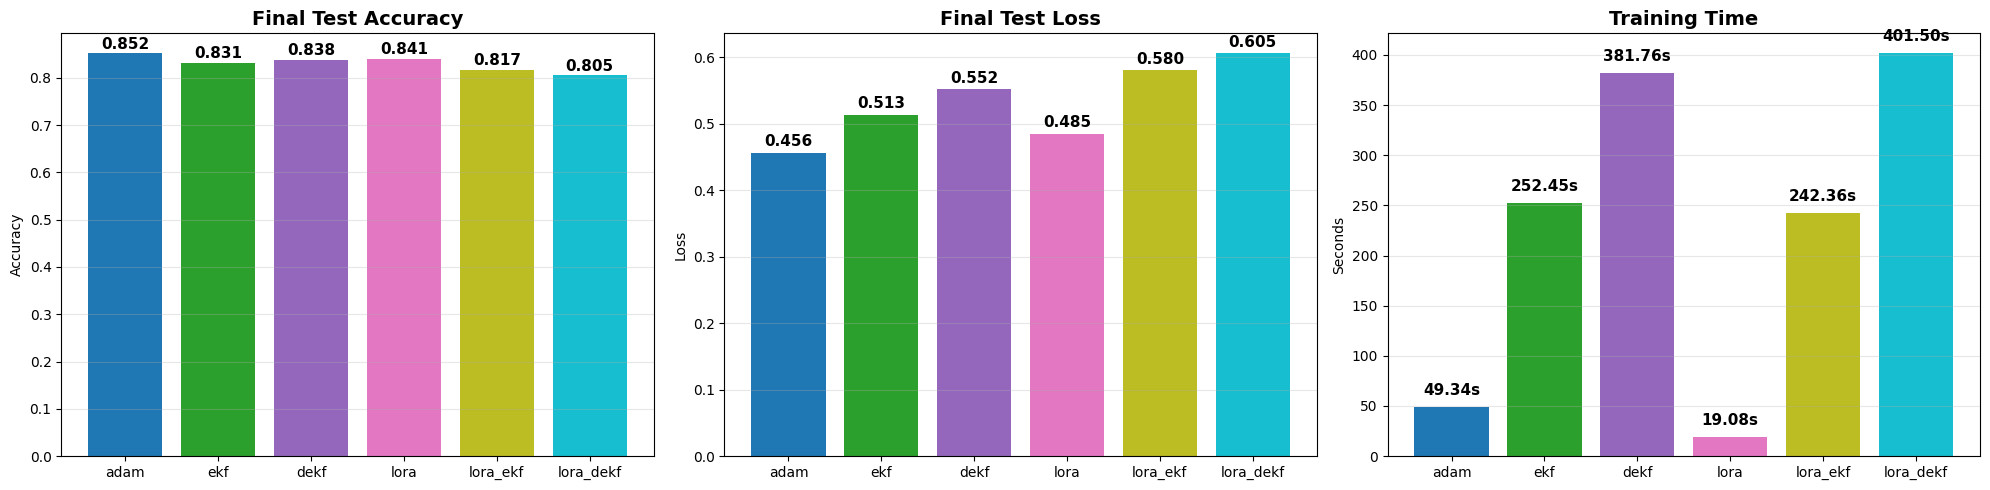

In [2]:
# ============================================================================
# FINAL RESULTS — SINGLE ROW, THREE SUBPLOTS
# ============================================================================

def plot_final_results_row(results):
    methods = list(results.keys())
    colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # ---------------------------------------
    # 1. Final Test Accuracy
    # ---------------------------------------
    ax = axes[0]
    accs = [results[m]['test_acc'] for m in methods]
    bars = ax.bar(methods, accs, color=colors)
    ax.set_title("Final Test Accuracy", fontsize=14, fontweight="bold")
    ax.set_ylabel("Accuracy")
    ax.grid(True, axis='y', alpha=0.3)

    for i, v in enumerate(accs):
        ax.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=11, fontweight='bold')

    # ---------------------------------------
    # 2. Final Test Loss
    # ---------------------------------------
    ax = axes[1]
    losses = [results[m]['test_loss'] for m in methods]
    bars = ax.bar(methods, losses, color=colors)
    ax.set_title("Final Test Loss", fontsize=14, fontweight="bold")
    ax.set_ylabel("Loss")
    ax.grid(True, axis='y', alpha=0.3)

    for i, v in enumerate(losses):
        ax.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=11, fontweight='bold')

    # ---------------------------------------
    # 3. Training Time
    # ---------------------------------------
    ax = axes[2]
    times = [results[m]['time'] for m in methods]
    bars = ax.bar(methods, times, color=colors)
    ax.set_title("Training Time", fontsize=14, fontweight="bold")
    ax.set_ylabel("Seconds")
    ax.grid(True, axis='y', alpha=0.3)

    for i, v in enumerate(times):
        ax.text(i, v + max(times)*0.03, f"{v:.2f}s", ha='center',
                fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()
plot_final_results_row(results)
